<a href="https://colab.research.google.com/github/PedroIvoLeite/Colab/blob/main/V_2_0_Projeto_Ci%C3%A9ncia_de_Dados_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação da Complexidade Técnico‑Linguística de Diagnósticos e Procedimentos Médicos do SUS

**Instituto Federal da Paraíba (IFPB) — Mestrado Profissional em Tecnologia da Informação**
**Disciplina:** Ciência de Dados — 2026.1  ·  **Docentes:** Damires Souza e Alex Cunha

**Equipe/responsável:** Lucas Matheus Santos da Silva

---

### Resumo
Este projeto constrói um *dataset* rotulado, a partir de fontes públicas oficiais de saúde
(CID‑10 e SIGTAP/DataSUS), para **classificar diagnósticos e procedimentos médicos em três
níveis de complexidade técnico‑linguística: baixa, média e alta**. A partir das descrições
oficiais são derivados atributos textuais (nº de palavras, nº de caracteres, nº de termos
técnicos, presença de siglas e de abreviações), define‑se uma variável‑alvo por regras
heurísticas e aplica‑se uma **árvore de decisão** para interpretar quais atributos mais
influenciam a complexidade. O trabalho dialoga com o tema do mestrado (Traduz Saúde, que
*simplifica* a linguagem médica), mas mantém o escopo da disciplina: **medir e classificar**
a complexidade da linguagem original.

> **Como executar:** rode as células na ordem (menu *Ambiente de execução → Executar tudo*,
> ou célula a célula com `Shift+Enter`). O notebook funciona **offline** com uma amostra de
> demonstração embutida e, opcionalmente, baixa os dados completos do DataSUS (Seção 3.1).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Introdução

### Contextualização e motivação
Documentos médicos — diagnósticos, laudos e procedimentos — são descritos em linguagem técnica,
com termos especializados, siglas e abreviações próprias da área da saúde. Essa linguagem
dificulta a compreensão por parte de pessoas que não atuam na saúde, comprometendo o que a
literatura chama de **letramento em saúde** (*health literacy*). Bases públicas do SUS, como o
**DataSUS/SIGTAP** (procedimentos) e a **CID‑10** (diagnósticos), descrevem de forma padronizada
milhares desses itens, o que permite analisá‑los de maneira sistemática.

### Problema de Ciência de Dados
O problema consiste em **construir um dataset rotulado para classificar diagnósticos e
procedimentos médicos em níveis de complexidade técnico‑linguística (baixa, média, alta)**.
Especificamente, o trabalho:
1. coleta descrições oficiais de diagnósticos e procedimentos;
2. extrai atributos textuais (palavras, caracteres, termos técnicos, siglas, abreviações);
3. cria uma variável‑alvo de complexidade por regras heurísticas;
4. aplica uma árvore de decisão para **interpretar** quais atributos mais influenciam a
   classificação;
5. gera visualizações e um indicador para apoiar a análise.

O diferencial está em **construir um dataset próprio a partir de fontes públicas** e aplicar
técnicas de Ciência de Dados para transformar descrições médicas em atributos analisáveis.

## 2. Trabalhos relacionados

> **(Confirme os dados bibliográficos completos antes da entrega — marcados com `[VERIFICAR]`.)**

1. **Simplificação textual em Português (Scalercio et al., ACL 2025)** `[VERIFICAR]` — trabalho de
   simplificação de sentenças em português que evidencia a dificuldade de leitura de textos
   técnicos e propõe abordagens automáticas; relaciona‑se a este projeto por tratar de
   complexidade linguística em PT, embora não foque na rotulagem de descrições clínicas do SUS.
2. **Simplificação de textos jurídicos PT‑BR (Pereira et al., BRACIS 2024)** `[VERIFICAR]` — aplica
   modelos de linguagem à simplificação de textos especializados (domínio jurídico); compartilha
   a motivação de tornar linguagem técnica acessível, mas não constrói um dataset de complexidade
   no domínio da saúde como o proposto aqui.
3. **(Opcional) Estudo de letramento em saúde no Brasil (Tabak et al., 2025)** `[VERIFICAR]` —
   fundamenta a relevância do problema: baixo letramento em saúde está associado a piores
   desfechos, motivando ferramentas que mensurem/atenuem a complexidade.

**Diferença para este trabalho:** os relacionados focam em *simplificar* texto; aqui o foco é
*construir um dataset rotulado e classificar/interpretar* a complexidade da linguagem médica
oficial, usando atributos interpretáveis e árvore de decisão.

## 3. Metodologia

O *pipeline* de construção do dataset segue as etapas abaixo (Figura 1). Cada etapa é detalhada
nas subseções 3.1 a 3.6.

In [3]:
# ============================================================
# SETUP — bibliotecas e configurações globais
# ============================================================
import re, io, zipfile, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# Estilo dos gráficos: fundo branco, padrão acadêmico
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "figure.dpi": 110, "font.size": 11,
})
PALETA = {"baixa": "#4C9F70", "media": "#E1A100", "alta": "#C44E52"}
ORDEM = ["baixa", "media", "alta"]
print("Ambiente configurado. pandas", pd.__version__)

Ambiente configurado. pandas 2.2.2


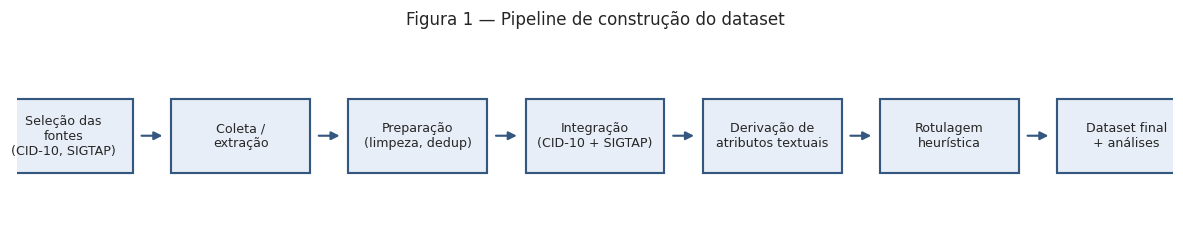

In [4]:
# ============================================================
# FIGURA 1 — Pipeline de construção/enriquecimento do dataset
# ============================================================
fig, ax = plt.subplots(figsize=(11, 2.4))
etapas = ["Seleção das\nfontes\n(CID-10, SIGTAP)", "Coleta /\nextração",
          "Preparação\n(limpeza, dedup)", "Integração\n(CID-10 + SIGTAP)",
          "Derivação de\natributos textuais", "Rotulagem\nheurística", "Dataset final\n+ análises"]
n = len(etapas); x = np.linspace(0.04, 0.96, n)
for i, (xi, txt) in enumerate(zip(x, etapas)):
    ax.add_patch(plt.Rectangle((xi-0.06, 0.32), 0.12, 0.36, facecolor="#E8EEF7",
                 edgecolor="#33577E", lw=1.4, zorder=2))
    ax.text(xi, 0.5, txt, ha="center", va="center", fontsize=8.3, zorder=3)
    if i < n-1:
        ax.annotate("", xy=(x[i+1]-0.065, 0.5), xytext=(xi+0.065, 0.5),
                    arrowprops=dict(arrowstyle="-|>", color="#33577E", lw=1.4))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
ax.set_title("Figura 1 — Pipeline de construção do dataset", fontsize=11, pad=6)
plt.tight_layout(); plt.savefig("fig1_pipeline.png", bbox_inches="tight"); plt.show()



---


# 4. Geração  do Dataset Consolidado

### Upload de dados adicionais para o Merge Final

Por favor, faça o upload dos arquivos `tb_procedimento.txt` e `tb_cid.txt` para que o merge final possa ser realizado. Note que estes são arquivos específicos para a seção "Novo CID / Procedimento Consolidado" e podem ter uma estrutura diferente dos arquivos usados anteriormente.

In [8]:
import pandas as pd
from google.colab import files
import os

# --- Helper function to handle file upload and renaming ---
def upload_and_rename_file(expected_filename):
    if not os.path.exists(expected_filename):
        print(f"Please upload '{expected_filename}':")
        uploaded_files = files.upload()
        if uploaded_files:
            uploaded_actual_name = list(uploaded_files.keys())[0]
            if uploaded_actual_name != expected_filename:
                if os.path.exists(expected_filename):
                    os.remove(expected_filename)
                    print(f"Removed old '{expected_filename}'.")
                os.rename(uploaded_actual_name, expected_filename)
                print(f"Renamed '{uploaded_actual_name}' to '{expected_filename}'.")
            print(f"'{expected_filename}' uploaded successfully.")
        else:
            print(f"Warning: No file uploaded for '{expected_filename}'. Please ensure it's in the current directory or upload it manually.")
    else:
        print(f"'{expected_filename}' already exists.")

# --- Ensure all necessary files are uploaded or exist ---
upload_and_rename_file("tb_procedimento.txt")
upload_and_rename_file("tb_cid.txt")
upload_and_rename_file("rl_procedimento_cid.txt")

# PROCEDIMENTOS
procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        'CO_PROCEDIMENTO',
        'NO_PROCEDIMENTO',
        'TP_COMPLEXIDADE',
        'TP_SEXO',
        'QT_MAXIMA_EXECUCAO',
        'QT_DIAS_PERMANENCIA',
        'QT_PONTOS',
        'VL_IDADE_MINIMA',
        'VL_IDADE_MAXIMA',
        'VL_SH',
        'VL_SA',
        'VL_SP',
        'CO_FINANCIAMENTO',
        'CO_RUBRICA',
        'QT_TEMPO_PERMANENCIA',
        'DT_COMPETENCIA'
    ],
    dtype=str,
    encoding='latin-1'
)

# RELAÇÃO PROCEDIMENTO ↔ CID
proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10,4,1,6],
    names=[
        'CO_PROCEDIMENTO',
        'CO_CID',
        'ST_PRINCIPAL',
        'DT_COMPETENCIA'
    ],
    dtype=str,
    encoding='latin-1'
)

# CID
cid = pd.read_fwf(
    "tb_cid.txt",
    widths=[4,100,1,1,1,4],
    names=[
        'CO_CID',
        'NO_CID',
        'TP_AGRAVO',
        'TP_SEXO',
        'TP_ESTADIO',
        'VL_CAMPOS_IRRADIADOS'
    ],
    dtype=str,
    encoding='latin-1'
)

# MERGE FINAL
resultado = (
    proc_cid
    .merge(
        procedimentos[
            ['CO_PROCEDIMENTO','NO_PROCEDIMENTO']
        ],
        on='CO_PROCEDIMENTO',
        how='left'
    )
    .merge(
        cid[
            ['CO_CID','NO_CID']
        ],
        on='CO_CID',
        how='left'
    )
)

print(resultado.head())

'tb_procedimento.txt' already exists.
'tb_cid.txt' already exists.
'rl_procedimento_cid.txt' already exists.
  CO_PROCEDIMENTO CO_CID ST_PRINCIPAL DT_COMPETENCIA  \
0      0201010038    C73            S         202605   
1      0201010038   D093            S         202605   
2      0201010038    D34            S         202605   
3      0201010038   D440            S         202605   
4      0201010046   C211            S         202605   

                 NO_PROCEDIMENTO  \
0  BIOPSIA CIRURGICA DE TIREOIDE   
1  BIOPSIA CIRURGICA DE TIREOIDE   
2  BIOPSIA CIRURGICA DE TIREOIDE   
3  BIOPSIA CIRURGICA DE TIREOIDE   
4   BIOPSIA DE ANUS E CANAL ANAL   

                                              NO_CID  
0             Neoplasia maligna da glândula tireóide  
1  Carcinoma in situ da tireóide e de outras glân...  
2             Neoplasia benigna da glândula tireóide  
3  Neoplasia de comportamento incerto ou desconhe...  
4                    Neoplasia maligna do canal anal  


### Confirmação da Leitura dos Arquivos

Os arquivos `tb_procedimento.txt`, `tb_cid.txt` e `rl_procedimento_cid.txt` foram lidos na célula anterior (`fII46MFUYtkY`). Abaixo, você pode ver as primeiras linhas de cada DataFrame resultante:

In [6]:
print('Primeiras linhas do DataFrame `procedimentos` (tb_procedimento.txt):')
display(procedimentos.head())

print('\nPrimeiras linhas do DataFrame `proc_cid` (rl_procedimento_cid.txt):')
display(proc_cid.head())

print('\nPrimeiras linhas do DataFrame `cid` (tb_cid.txt):')
display(cid.head())

Primeiras linhas do DataFrame `procedimentos` (tb_procedimento.txt):


,CO_PROCEDIMENTO,NO_PROCEDIMENTO,TP_COMPLEXIDADE,TP_SEXO,QT_MAXIMA_EXECUCAO,QT_DIAS_PERMANENCIA,QT_PONTOS,VL_IDADE_MINIMA,VL_IDADE_MAXIMA,VL_SH,VL_SA,VL_SP,CO_FINANCIAMENTO,CO_RUBRICA,QT_TEMPO_PERMANENCIA,DT_COMPETENCIA
0,0101010010,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,1,N,9999,9999,0000,9999,9999,000000000000,000000000000,000000000000,01,NaN,9999,202605
1,0101010028,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,2,I,9999,9999,0000,0084,1571,000000000000,000000000270,000000000000,06,NaN,9999,202605
2,0101010036,PRÁTICA CORPORAL / ATIVIDADE FÍSICA EM GRUPO,1,I,9999,9999,0000,0072,1571,000000000000,000000000000,000000000000,01,NaN,9999,202605
3,0101010095,PREVENÇÃO DA COVID-19 NAS ESCOLAS,1,I,9999,9999,0000,0000,1571,000000000000,000000000000,000000000000,01,NaN,9999,202605
4,0101010109,ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...,1,I,9999,9999,0000,0000,1571,000000000000,000000000000,000000000000,07,NaN,9999,202605



Primeiras linhas do DataFrame `proc_cid` (rl_procedimento_cid.txt):


,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA
0,0201010038,C73,S,202605
1,0201010038,D093,S,202605
2,0201010038,D34,S,202605
3,0201010038,D440,S,202605
4,0201010046,C211,S,202605



Primeiras linhas do DataFrame `cid` (tb_cid.txt):


,CO_CID,NO_CID,TP_AGRAVO,TP_SEXO,TP_ESTADIO,VL_CAMPOS_IRRADIADOS
0,A00,Cólera,0,I,N,0000
1,A000,"Cólera devida a Vibrio Cholerae 01, biótipo Ch...",2,I,N,0000
2,A001,"Cólera devida a Vibrio Cholerae 01, biótipo El...",2,I,N,0000
3,A009,Cólera não especificada,2,I,N,0000
4,A01,Febres tifóide e paratifóide,0,I,N,0000


In [10]:
df = resultado
df.head()

,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID
0,0201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide
1,0201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...
2,0201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide
3,0201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...
4,0201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal


In [11]:
df.describe()

,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID
count,81864,81864,81864,81864,81864,81864
unique,2896,8205,2,1,2895,8194
top,0203020030,B92,S,202605,EXAME ANATOMO-PATOLÓGICO PARA CONGELAMENTO / P...,Seqüelas de hanseníase [lepra]
freq,4448,162,81502,81864,4448,162


In [ ]:
df

,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID
0,0201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide
1,0201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...
2,0201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide
3,0201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...
4,0201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal
...,...,...,...,...,...,...
81859,0906010055,N95,S,202605,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,Transtornos da menopausa e da perimenopausa
81860,0906010055,N96,S,202605,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,Abortamento habitual
81861,0906010055,N97,S,202605,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,Infertilidade feminina
81862,0906010055,N98,S,202605,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,Complicações associadas a fecundação artificial


In [12]:
df.shape

(81864, 6)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CO_PROCEDIMENTO  81864 non-null  object
 1   CO_CID           81864 non-null  object
 2   ST_PRINCIPAL     81864 non-null  object
 3   DT_COMPETENCIA   81864 non-null  object
 4   NO_PROCEDIMENTO  81864 non-null  object
 5   NO_CID           81864 non-null  object
dtypes: object(6)
memory usage: 3.7+ MB


In [14]:
df.nunique()

,0
CO_PROCEDIMENTO,2896
CO_CID,8205
ST_PRINCIPAL,2
DT_COMPETENCIA,1
NO_PROCEDIMENTO,2895
NO_CID,8194


# 4.1 Incluir o Número de Palavras dos Procedimentos

In [15]:
df['QT_PALAVRAS_PROCEDIMENTO'] = df['NO_PROCEDIMENTO'].apply(lambda x: len(str(x).split()))
display(df.head())

,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID,QT_PALAVRAS_PROCEDIMENTO
0,0201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide,4
1,0201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...,4
2,0201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide,4
3,0201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...,4
4,0201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal,6


## 4.2 Incluir a Complexidade, Termos Técnicos e Abreviações dos Procedimentos

In [16]:
# Merge TP_COMPLEXIDADE from 'procedimentos' into 'df' to get the base complexity type
df = df.merge(
    procedimentos[['CO_PROCEDIMENTO', 'TP_COMPLEXIDADE']],
    on='CO_PROCEDIMENTO',
    how='left'
)

# Mapear TP_COMPLEXIDADE para a coluna 'complexidade' em 'df'
mapa_complexidade = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}
df["complexidade"] = df["TP_COMPLEXIDADE"].map(mapa_complexidade)

# Calcular qtd_caracteres
df['qtd_caracteres'] = df['NO_PROCEDIMENTO'].apply(lambda x: len(str(x)))

# Funções para calcular termos técnicos, siglas e abreviações (placeholders)
import re

def count_technical_terms(text):
    # This is a basic placeholder. A more robust implementation would use a specialized lexicon.
    # For now, it counts words that appear to be technical (e.g., all caps, or specific patterns).
    technical_term_pattern = r'\b[A-Z]{3,}\b|\b\w+\d+\w*\b'
    return len(re.findall(technical_term_pattern, str(text)))

def has_acronym(text):
    # Checks for sequences of 2 or more uppercase letters, indicating a potential acronym.
    acronym_pattern = r'\b[A-Z]{2,}\b'
    return 1 if re.search(acronym_pattern, str(text)) else 0

def has_abbreviation(text):
    # Checks for common abbreviation patterns, like words followed by a dot.
    abbreviation_pattern = r'\b\w+\.\b'
    return 1 if re.search(abbreviation_pattern, str(text).lower()) else 0

df['qtd_termos_tecnicos'] = df['NO_PROCEDIMENTO'].apply(count_technical_terms)
df['possui_sigla'] = df['NO_PROCEDIMENTO'].apply(has_acronym)
df['possui_abreviacao'] = df['NO_PROCEDIMENTO'].apply(has_abbreviation)

print("DataFrame 'df' enriquecido com colunas de complexidade e atributos textuais.")
display(df.head())
display(df.info())

DataFrame 'df' enriquecido com colunas de complexidade e atributos textuais.


,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID,QT_PALAVRAS_PROCEDIMENTO,TP_COMPLEXIDADE,complexidade,qtd_caracteres,qtd_termos_tecnicos,possui_sigla,possui_abreviacao
0,0201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
1,0201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...,4,2,Média Complexidade,29,3,1,0
2,0201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
3,0201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...,4,2,Média Complexidade,29,3,1,0
4,0201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal,6,2,Média Complexidade,28,4,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CO_PROCEDIMENTO           81864 non-null  object
 1   CO_CID                    81864 non-null  object
 2   ST_PRINCIPAL              81864 non-null  object
 3   DT_COMPETENCIA            81864 non-null  object
 4   NO_PROCEDIMENTO           81864 non-null  object
 5   NO_CID                    81864 non-null  object
 6   QT_PALAVRAS_PROCEDIMENTO  81864 non-null  int64 
 7   TP_COMPLEXIDADE           81864 non-null  object
 8   complexidade              71683 non-null  object
 9   qtd_caracteres            81864 non-null  int64 
 10  qtd_termos_tecnicos       81864 non-null  int64 
 11  possui_sigla              81864 non-null  int64 
 12  possui_abreviacao         81864 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 8.1+ MB


None

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CO_PROCEDIMENTO           81864 non-null  object
 1   CO_CID                    81864 non-null  object
 2   ST_PRINCIPAL              81864 non-null  object
 3   DT_COMPETENCIA            81864 non-null  object
 4   NO_PROCEDIMENTO           81864 non-null  object
 5   NO_CID                    81864 non-null  object
 6   QT_PALAVRAS_PROCEDIMENTO  81864 non-null  int64 
 7   TP_COMPLEXIDADE           81864 non-null  object
 8   complexidade              71683 non-null  object
 9   qtd_caracteres            81864 non-null  int64 
 10  qtd_termos_tecnicos       81864 non-null  int64 
 11  possui_sigla              81864 non-null  int64 
 12  possui_abreviacao         81864 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 8.1+ MB




---



# 4.3 Salvando o Dataset Consolidado

In [18]:
# Definindo o caminho completo para salvar o arquivo CSV no Google Drive, incluindo os novos tse_x e tse_y
output_file_path = '/content/CID_Consolidado.csv'

# Salvando o DataFrame atualizado em um novo arquivo CSV, sem o índice do pandas
df.to_csv(output_file_path, index=False)

print(f"✅ DataFrame 'df' atualizado e salvo com sucesso em: {output_file_path}")

✅ DataFrame 'df' atualizado e salvo com sucesso em: /content/CID_Consolidado.csv




---

# 5. Análise Exploratória dos Dados (EDA)

# Carregando as Bibliotecas Necessárias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
Consolidated_df = pd.read_csv('/content/CID_Consolidado.csv')
print("Dataset 'Consolidated_df.csv' carregado com sucesso!")
display(Consolidated_df.head())

Dataset 'Consolidated_df.csv' carregado com sucesso!


,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID,QT_PALAVRAS_PROCEDIMENTO,TP_COMPLEXIDADE,complexidade,qtd_caracteres,qtd_termos_tecnicos,possui_sigla,possui_abreviacao
0,201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
1,201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...,4,2,Média Complexidade,29,3,1,0
2,201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
3,201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...,4,2,Média Complexidade,29,3,1,0
4,201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal,6,2,Média Complexidade,28,4,1,0


## 5.1. Informações do Dataset

In [ ]:
Consolidated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CO_PROCEDIMENTO           81864 non-null  int64 
 1   CO_CID                    81864 non-null  object
 2   ST_PRINCIPAL              81864 non-null  object
 3   DT_COMPETENCIA            81864 non-null  int64 
 4   NO_PROCEDIMENTO           81864 non-null  object
 5   NO_CID                    81864 non-null  object
 6   QT_PALAVRAS_PROCEDIMENTO  81864 non-null  int64 
 7   TP_COMPLEXIDADE           81864 non-null  int64 
 8   complexidade              71683 non-null  object
 9   qtd_caracteres            81864 non-null  int64 
 10  qtd_termos_tecnicos       81864 non-null  int64 
 11  possui_sigla              81864 non-null  int64 
 12  possui_abreviacao         81864 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 8.1+ MB


# 5.2 Quais dignósticos possuem mais procedimentos associados?

In [ ]:
resultado.groupby('CO_CID')\
          .size()\
          .sort_values(ascending=False)

,0
CO_CID,
B92,162
A309,151
A305,150
A303,142
B91,130
...,...
K63,1
K62,1
K65,1


# 5.3 Quantos diagnósticos cada procedimento atende?

In [ ]:
# Relação procedimento ↔ CID

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10, 4, 1, 6],
    names=[
        "CO_PROCEDIMENTO",
        "CO_CID",
        "ST_PRINCIPAL",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# Procedimentos
procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# CID (also include latin-1 for consistency, although not directly causing the error here)
cid = pd.read_fwf(
    "tb_cid.txt",
    widths=[4,100,1,1,1,4],
    names=[
        'CO_CID',
        'NO_CID',
        'TP_AGRAVO',
        'TP_SEXO',
        'TP_ESTADIO',
        'VL_CAMPOS_IRRADIADOS'
    ],
    dtype=str,
    encoding='latin-1'
)

# Quantos diagnósticos cada procedimento atende
diagnosticos_por_procedimento = (
    proc_cid
    .groupby("CO_PROCEDIMENTO")["CO_CID"]
    .nunique()
    .reset_index(name="QT_DIAGNOSTICOS")
    .merge(
        procedimentos[["CO_PROCEDIMENTO", "NO_PROCEDIMENTO"]],
        on="CO_PROCEDIMENTO",
        how="left"
    )
    .sort_values("QT_DIAGNOSTICOS", ascending=False)
)

print(diagnosticos_por_procedimento.head(30))

# Salvar resultado
diagnosticos_por_procedimento.to_csv(
    "diagnosticos_por_procedimento.csv",
    index=False,
    encoding="utf-8-sig"
)

     CO_PROCEDIMENTO  QT_DIAGNOSTICOS  \
57        0203020030             4448   
54        0203010035             4421   
185       0302050027              757   
2785      0701020571              738   
2786      0701020580              705   
2714      0701010193              675   
2713      0701010185              634   
175       0302020039              547   
586       0304100013              540   
587       0304100021              539   
353       0303130067              526   
174       0302020020              525   
400       0304010111              509   
115       0301050074              474   
186       0302060014              446   
187       0302060022              422   
184       0302050019              414   
137       0301080038              407   
138       0301080046              407   
136       0301080020              407   
147       0301080291              407   
144       0301080240              407   
139       0301080194              407   
143       030108

# 5.4 Análise por capítulos do CID

           CAPITULO_CID  QT_PROCEDIMENTOS
20              Traumas               870
11           Neoplasias               800
2            Congênitas               609
17     Sangue/Imunidade               493
10  Musculoesqueléticas               435
8           Infecciosas               406
19      Sistema Nervoso               367
1         Circulatórias               351
6        Geniturinárias               328
3            Digestivas               239
4            Endócrinas               238
12        Olhos/Ouvidos               231
5         Fatores Saúde               212
14                 Pele               136
16        Respiratórias               133
18      Sinais/Sintomas               123
9               Mentais               117
15           Perinatais                50
7        Gravidez/Parto                47
0       Causas Externas                45
13               Outros                 3


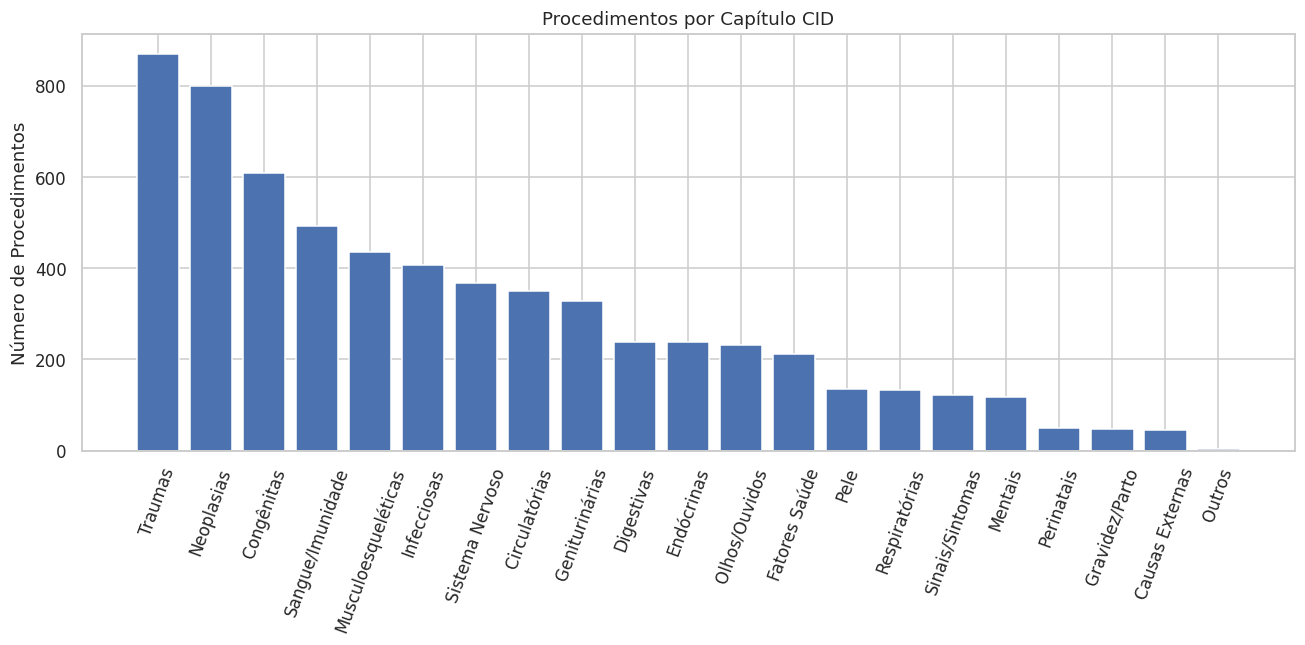

In [ ]:
#########################################
# Ler relação Procedimento ↔ CID
#########################################

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10,4,1,6],
    names=[
        "CO_PROCEDIMENTO",
        "CO_CID",
        "ST_PRINCIPAL",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

#########################################
# Ler procedimentos
#########################################

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

#########################################
# Definir capítulos CID
#########################################

def capitulo_cid(cid):
    letra = cid[0]
    capitulos = {
        'A':'Infecciosas',
        'B':'Infecciosas',
        'C':'Neoplasias',
        'D':'Sangue/Imunidade',
        'E':'Endócrinas',
        'F':'Mentais',
        'G':'Sistema Nervoso',
        'H':'Olhos/Ouvidos',
        'I':'Circulatórias',
        'J':'Respiratórias',
        'K':'Digestivas',
        'L':'Pele',
        'M':'Musculoesqueléticas',
        'N':'Geniturinárias',
        'O':'Gravidez/Parto',
        'P':'Perinatais',
        'Q':'Congênitas',
        'R':'Sinais/Sintomas',
        'S':'Traumas',
        'T':'Traumas',
        'V':'Causas Externas',
        'W':'Causas Externas',
        'X':'Causas Externas',
        'Y':'Causas Externas',
        'Z':'Fatores Saúde'
    }
    return capitulos.get(letra,"Outros")

#########################################
# Criar capítulo
#########################################

proc_cid["CAPITULO_CID"] = (
    proc_cid["CO_CID"]
    .astype(str)
    .apply(capitulo_cid)
)

#########################################
# Quantidade de procedimentos
# por capítulo
#########################################

capitulos = (

    proc_cid
    .groupby("CAPITULO_CID")["CO_PROCEDIMENTO"]
    .nunique()
    .reset_index(
        name="QT_PROCEDIMENTOS"
    )
    .sort_values(
        "QT_PROCEDIMENTOS",
        ascending=False
    )
)

print(capitulos)

#########################################
# Salvar
#########################################

capitulos.to_csv(

    "procedimentos_por_capitulo_cid.csv",
    index=False,
    encoding="utf-8-sig"
)

#########################################
# Gráfico
#########################################

plt.figure(
    figsize=(12,6)
)
plt.bar(
    capitulos["CAPITULO_CID"],
    capitulos["QT_PROCEDIMENTOS"]
)
plt.xticks(
    rotation=70
)
plt.ylabel(
    "Número de Procedimentos"
)
plt.title(
    "Procedimentos por Capítulo CID"
)
plt.tight_layout()
plt.savefig(
    "procedimentos_por_capitulo.png",
    dpi=300
)
plt.show()

# 5.5 Heatmap Capítulo do CD x Grupo SIGTAB- New

GRUPO_SIGTAP         Ações complementares  Medicamentos  \
CAPITULO_CID                                              
Causas Externas                         0             0   
Circulatórias                           0            32   
Congênitas                              0            14   
Digestivas                              0            33   
Endócrinas                              0           102   
Fatores Saúde                           0            33   
Geniturinárias                          0            37   
Gravidez/Parto                          0             3   
Infecciosas                             0             8   
Mentais                                 0            30   
Musculoesqueléticas                     0            68   
Neoplasias                              0             0   
Olhos/Ouvidos                           0            20   
Outros                                  1             0   
Pele                                    0            38 

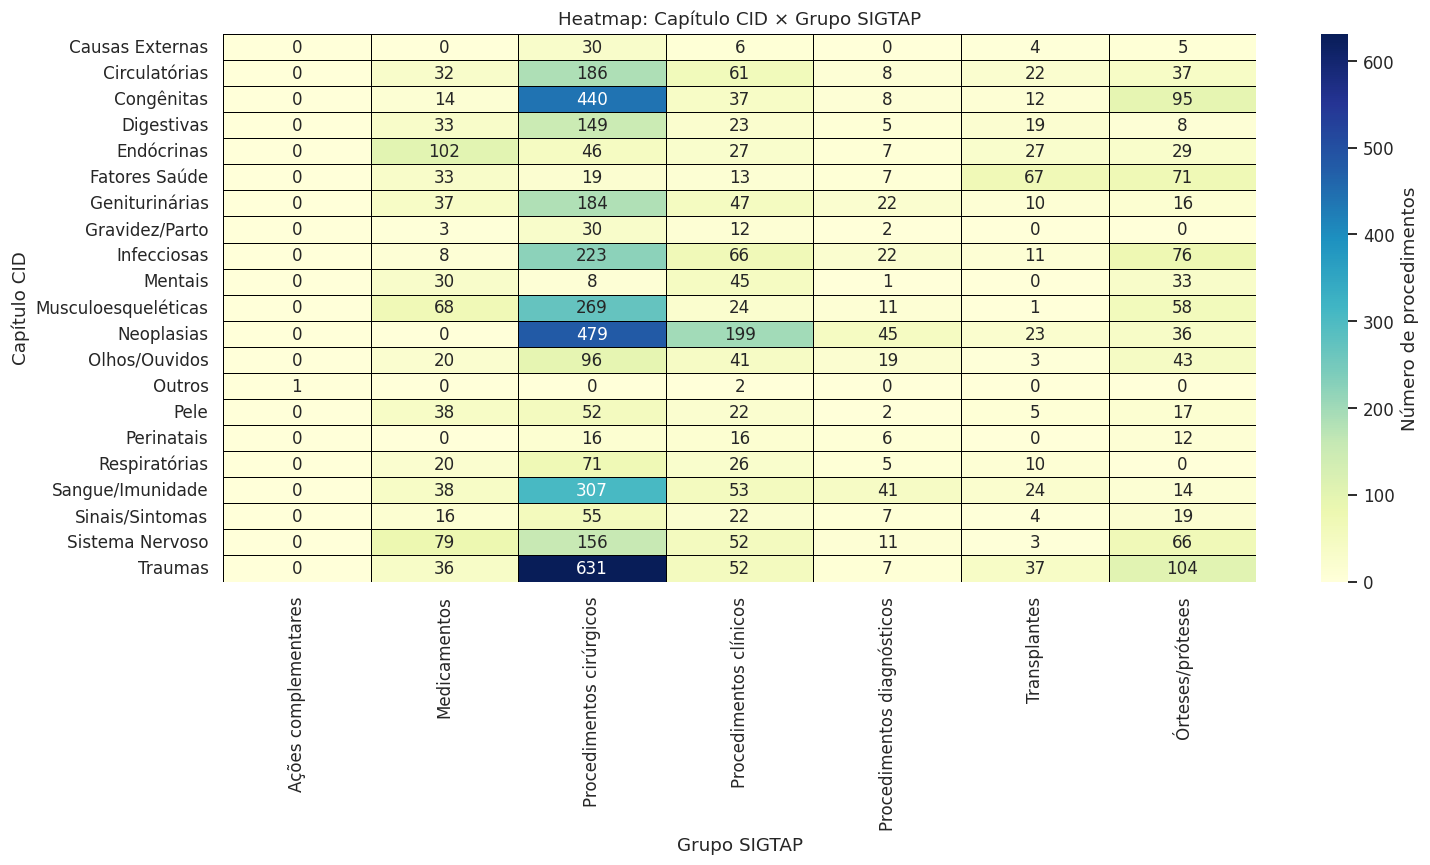

In [ ]:
# ==============================
# 1. Ler arquivos
# ==============================

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10, 4, 1, 6],
    names=["CO_PROCEDIMENTO", "CO_CID", "ST_PRINCIPAL", "DT_COMPETENCIA"],
    dtype=str,
    encoding='latin-1'
)

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# ==============================
# 2. Criar grupo SIGTAP
# ==============================

procedimentos["CO_GRUPO"] = procedimentos["CO_PROCEDIMENTO"].str[0:2]

mapa_grupo_sigtap = {
    "01": "Ações promoção/prevenção",
    "02": "Procedimentos diagnósticos",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes",
    "06": "Medicamentos",
    "07": "Órteses/próteses",
    "08": "Ações complementares"
}

procedimentos["GRUPO_SIGTAP"] = procedimentos["CO_GRUPO"].map(mapa_grupo_sigtap)

# ==============================
# 3. Criar capítulo CID
# ==============================

def capitulo_cid(cid):
    if pd.isna(cid) or len(str(cid)) == 0:
        return "Sem CID"

    letra = str(cid)[0]

    mapa = {
        'A':'Infecciosas',
        'B':'Infecciosas',
        'C':'Neoplasias',
        'D':'Sangue/Imunidade',
        'E':'Endócrinas',
        'F':'Mentais',
        'G':'Sistema Nervoso',
        'H':'Olhos/Ouvidos',
        'I':'Circulatórias',
        'J':'Respiratórias',
        'K':'Digestivas',
        'L':'Pele',
        'M':'Musculoesqueléticas',
        'N':'Geniturinárias',
        'O':'Gravidez/Parto',
        'P':'Perinatais',
        'Q':'Congênitas',
        'R':'Sinais/Sintomas',
        'S':'Traumas',
        'T':'Traumas',
        'V':'Causas Externas',
        'W':'Causas Externas',
        'X':'Causas Externas',
        'Y':'Causas Externas',
        'Z':'Fatores Saúde'
    }

    return mapa.get(letra, "Outros")


proc_cid["CAPITULO_CID"] = proc_cid["CO_CID"].astype(str).apply(capitulo_cid)

# ==============================
# 4. Merge
# ==============================

base = proc_cid.merge(
    procedimentos[["CO_PROCEDIMENTO", "NO_PROCEDIMENTO", "GRUPO_SIGTAP"]],
    on="CO_PROCEDIMENTO",
    how="left"
)

# ==============================
# 5. Criar matriz para heatmap
# ==============================

heatmap_data = pd.pivot_table(
    base,
    index="CAPITULO_CID",
    columns="GRUPO_SIGTAP",
    values="CO_PROCEDIMENTO",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

print(heatmap_data)

heatmap_data.to_csv(
    "heatmap_capitulo_cid_grupo_sigtap.csv",
    encoding="utf-8-sig"
)

# ==============================
# 6. Gerar heatmap com Matplotlib e Seaborn
# ==============================

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu', # Changed colormap to YlGnBu
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Número de procedimentos'}
)

plt.title("Heatmap: Capítulo CID × Grupo SIGTAP")
plt.xlabel("Grupo SIGTAP")
plt.ylabel("Capítulo CID")

plt.tight_layout()

plt.savefig(
    "heatmap_capitulo_cid_grupo_sigtap.png",
    dpi=300
)

plt.show()

# 5.6 Análise da Complexidade


=== Análise geral por complexidade ===
         COMPLEXIDADE  QT_PROCEDIMENTOS  QT_CIDS  QT_RELACOES
0   Alta Complexidade              1414     3160        26322
2  Média Complexidade              1292     7957        44937
1      Atenção Básica                23      198          424

=== Complexidade por Capítulo CID ===
COMPLEXIDADE         Alta Complexidade  Atenção Básica  Média Complexidade
CAPITULO_CID                                                              
Causas Externas                     19               0                  21
Circulatórias                      202               0                 112
Congênitas                         288               2                 224
Digestivas                          80               0                 151
Endócrinas                         174               0                  35
Fatores Saúde                       81               6                  52
Geniturinárias                      83               4                 22

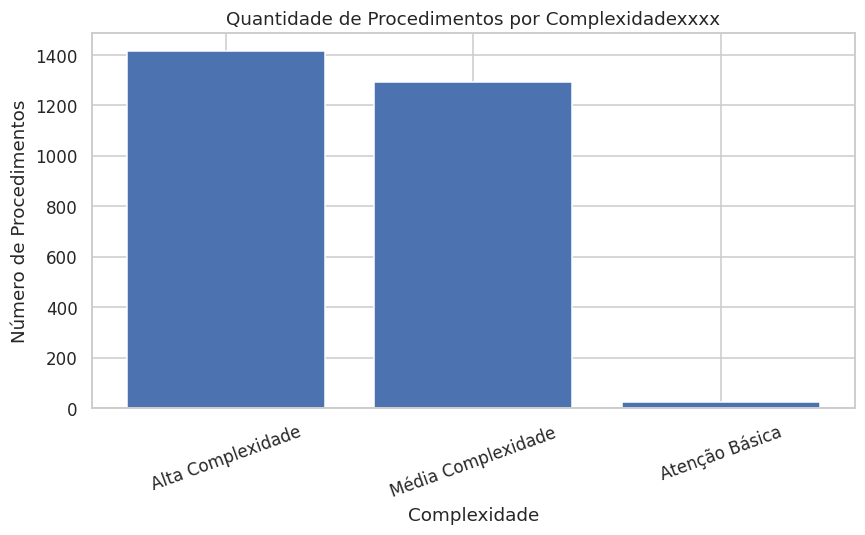

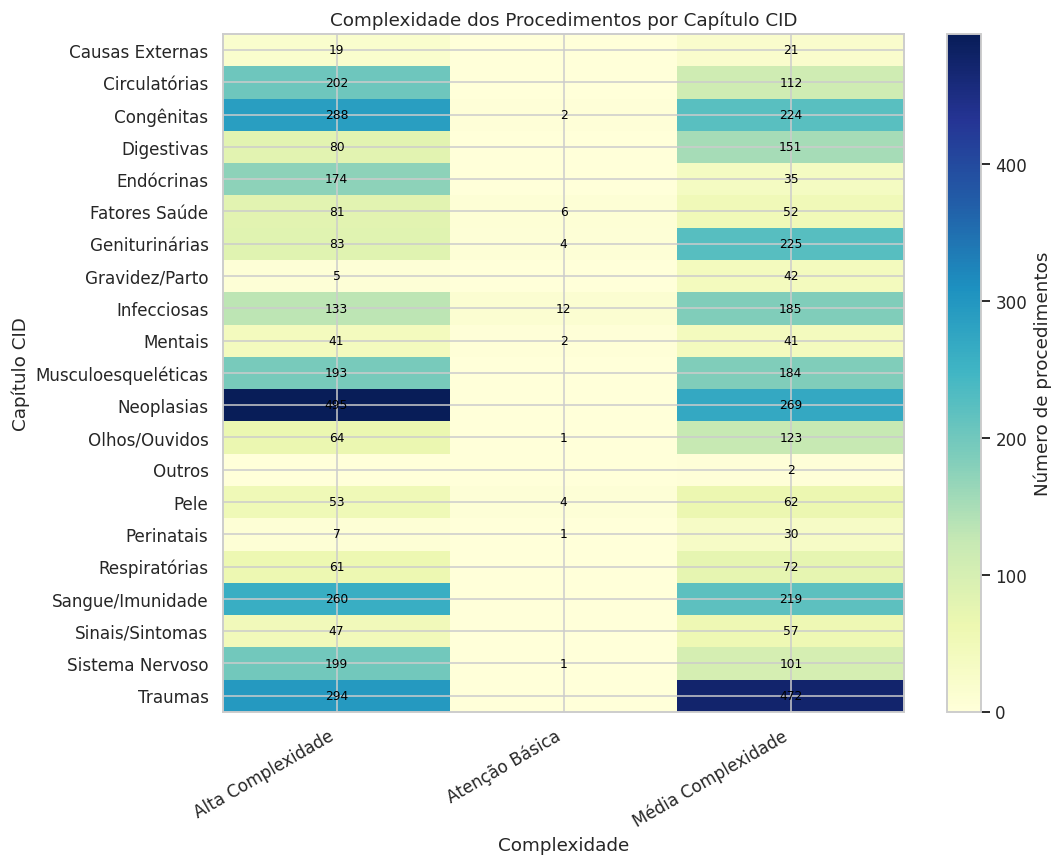


Arquivos gerados:
analise_complexidade_geral.csv
complexidade_por_capitulo_cid.csv
procedimentos_por_complexidade.png
heatmap_complexidade_capitulo_cid.png
procedimentos_alta_complexidade_por_cid.csv


In [ ]:
# ==============================
# 1. Ler relação Procedimento ↔ CID
# ==============================

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10, 4, 1, 6],
    names=["CO_PROCEDIMENTO", "CO_CID", "ST_PRINCIPAL", "DT_COMPETENCIA"],
    dtype=str,
    encoding='latin-1'
)

# ==============================
# 2. Ler procedimentos
# ==============================

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# ==============================
# 3. Mapear complexidade
# ==============================

mapa_complexidade = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}

procedimentos["COMPLEXIDADE"] = procedimentos["TP_COMPLEXIDADE"].map(mapa_complexidade)

# ==============================
# 4. Criar capítulo CID
# ==============================

def capitulo_cid(cid):
    if pd.isna(cid) or len(str(cid)) == 0:
        return "Sem CID"

    letra = str(cid)[0]

    mapa = {
        "A": "Infecciosas",
        "B": "Infecciosas",
        "C": "Neoplasias",
        "D": "Sangue/Imunidade",
        "E": "Endócrinas",
        "F": "Mentais",
        "G": "Sistema Nervoso",
        "H": "Olhos/Ouvidos",
        "I": "Circulatórias",
        "J": "Respiratórias",
        "K": "Digestivas",
        "L": "Pele",
        "M": "Musculoesqueléticas",
        "N": "Geniturinárias",
        "O": "Gravidez/Parto",
        "P": "Perinatais",
        "Q": "Congênitas",
        "R": "Sinais/Sintomas",
        "S": "Traumas",
        "T": "Traumas",
        "V": "Causas Externas",
        "W": "Causas Externas",
        "X": "Causas Externas",
        "Y": "Causas Externas",
        "Z": "Fatores Saúde"
    }

    return mapa.get(letra, "Outros")


proc_cid["CAPITULO_CID"] = proc_cid["CO_CID"].apply(capitulo_cid)

# ==============================
# 5. Merge
# ==============================

base = proc_cid.merge(
    procedimentos[
        [
            "CO_PROCEDIMENTO",
            "NO_PROCEDIMENTO",
            "TP_COMPLEXIDADE",
            "COMPLEXIDADE"
        ]
    ],
    on="CO_PROCEDIMENTO",
    how="left"
)

# ==============================
# 6. Tabela geral por complexidade
# ==============================

analise_complexidade = (
    base
    .groupby("COMPLEXIDADE")
    .agg(
        QT_PROCEDIMENTOS=("CO_PROCEDIMENTO", "nunique"),
        QT_CIDS=("CO_CID", "nunique"),
        QT_RELACOES=("CO_CID", "count")
    )
    .reset_index()
    .sort_values("QT_PROCEDIMENTOS", ascending=False)
)

print("\n=== Análise geral por complexidade ===")
print(analise_complexidade)

analise_complexidade.to_csv(
    "analise_complexidade_geral.csv",
    index=False,
    encoding="utf-8-sig"
)

# ==============================
# 7. Complexidade por capítulo CID
# ==============================

complexidade_capitulo = pd.pivot_table(
    base,
    index="CAPITULO_CID",
    columns="COMPLEXIDADE",
    values="CO_PROCEDIMENTO",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

print("\n=== Complexidade por Capítulo CID ===")
print(complexidade_capitulo)

complexidade_capitulo.to_csv(
    "complexidade_por_capitulo_cid.csv",
    encoding="utf-8-sig"
)

# ==============================
# 8. Gráfico de barras geral
# ==============================

plt.figure(figsize=(8,5))

plt.bar(
    analise_complexidade["COMPLEXIDADE"],
    analise_complexidade["QT_PROCEDIMENTOS"]
)

plt.title("Quantidade de Procedimentos por Complexidadexxxx")
plt.xlabel("Complexidade")
plt.ylabel("Número de Procedimentos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("procedimentos_por_complexidade.png", dpi=300)
plt.show()

# ==============================
# 9. Heatmap: capítulo CID × complexidade
# ==============================

plt.figure(figsize=(10,8))

img = plt.imshow(
    complexidade_capitulo,
    aspect="auto",
    cmap="YlGnBu"
)

plt.colorbar(img, label="Número de procedimentos")

plt.xticks(
    range(len(complexidade_capitulo.columns)),
    complexidade_capitulo.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(complexidade_capitulo.index)),
    complexidade_capitulo.index
)

for i in range(len(complexidade_capitulo.index)):
    for j in range(len(complexidade_capitulo.columns)):
        valor = complexidade_capitulo.iloc[i, j]
        if valor > 0:
            plt.text(
                j,
                i,
                str(valor),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

plt.title("Complexidade dos Procedimentos por Capítulo CID")
plt.xlabel("Complexidade")
plt.ylabel("Capítulo CID")
plt.tight_layout()
plt.savefig("heatmap_complexidade_capitulo_cid.png", dpi=300)
plt.show()

# ==============================
# 10. Procedimentos de alta complexidade
# ==============================

alta_complexidade = (
    base[base["COMPLEXIDADE"] == "Alta Complexidade"]
    [["CO_PROCEDIMENTO", "NO_PROCEDIMENTO", "CO_CID", "CAPITULO_CID"]]
    .drop_duplicates()
    .sort_values(["CAPITULO_CID", "CO_PROCEDIMENTO"])
)

alta_complexidade.to_csv(
    "procedimentos_alta_complexidade_por_cid.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivos gerados:")
print("analise_complexidade_geral.csv")
print("complexidade_por_capitulo_cid.csv")
print("procedimentos_por_complexidade.png")
print("heatmap_complexidade_capitulo_cid.png")
print("procedimentos_alta_complexidade_por_cid.csv")

# 5.7 Heatmap dos Procedimentos x Capítulos

O Heatmap Procedimentos × Capítulos CID', mostra a relação entre os 30 procedimentos mais frequentes e os capítulos da CID a que estão associados.

Interpretação do Heatmap:
Eixo Y (Vertical): Procedimentos

Lista os 30 NO_PROCEDIMENTO (Nomes dos Procedimentos) mais frequentes nos dados. Você pode ver nomes como "ACOLHIMENTO DIURNO DE PACIENTE EM CENTRO DE ATENÇÃO PSICOSSOCIAL", "EXAME ANATOMO-PATOLÓGICO PARA CONGELAMENTO", etc.
Eixo X (Horizontal): Capítulos CID

Representa os CAPITULOs da CID-10, como "Circulatórias", "Congênitas", "Digestivas", "Mentais", "Nervoso", "Traumas", etc.
Cores dos Blocos:

A intensidade da cor (azul, neste caso) indica a frequência ou o número de vezes que um determinado procedimento (linha) está associado a um capítulo específico da CID (coluna). Quanto mais escura a cor, maior o número de associações (o heatmap usa uma transformação logarítmica para suavizar as diferenças e tornar a visualização mais útil, então o log(1+n) na barra de cores significa que ele está mostrando o logaritmo natural de 1 mais o número de ocorrências, o que ajuda a visualizar grandes variações).
A barra de cores à direita ('log(1+n)') mostra a escala de valores representados pelas diferentes tonalidades de azul.
O que podemos observar:
Concentração de Associações: Você pode notar que alguns procedimentos estão fortemente associados a um ou poucos capítulos da CID. Por exemplo:

Procedimentos como "ACOLHIMENTO DIURNO DE PACIENTE EM CENTRO DE ATENÇÃO PSICOSSOCIAL" e outros relacionados a acolhimento de pacientes tendem a ter associações mais fortes com o capítulo Mentais.
"EXAME ANATOMO-PATOLÓGICO PARA CONGELAMENTO" e "EXAME DE CITOLOGIA" mostram associações em vários capítulos, mas podem ter concentrações mais escuras em capítulos como Neoplasias (que não está totalmente visível na imagem cortada, mas é esperado para exames patológicos).
Os procedimentos de "TRATAMENTO DE INTERCORRÊNCIAS CLÍNICAS DE PACIENTE ONCOLÓGICO" e "TRATAMENTO CLÍNICO DE PACIENTE ONCOLÓGICO" naturalmente se destacam no capítulo Neoplasias.
Padrões e Agrupamentos: O heatmap ajuda a identificar padrões. Se houver blocos de cores escuras em certas interseções, isso indica que há uma forte relação entre aqueles procedimentos e capítulos da CID.

Ausência de Associações: Blocos mais claros ou brancos (preenchidos com 0 no DataFrame subjacente) indicam que não há ou há pouquíssimas associações entre aquele procedimento e aquele capítulo da CID nos dados selecionados.

Este heatmap é excelente para visualizar rapidamente as áreas de maior cruzamento entre procedimentos e tipos de diagnósticos, auxiliando na compreensão das relações existentes nos dados e na validação de hipóteses sobre quais procedimentos estão ligados a quais condições médicas principais.

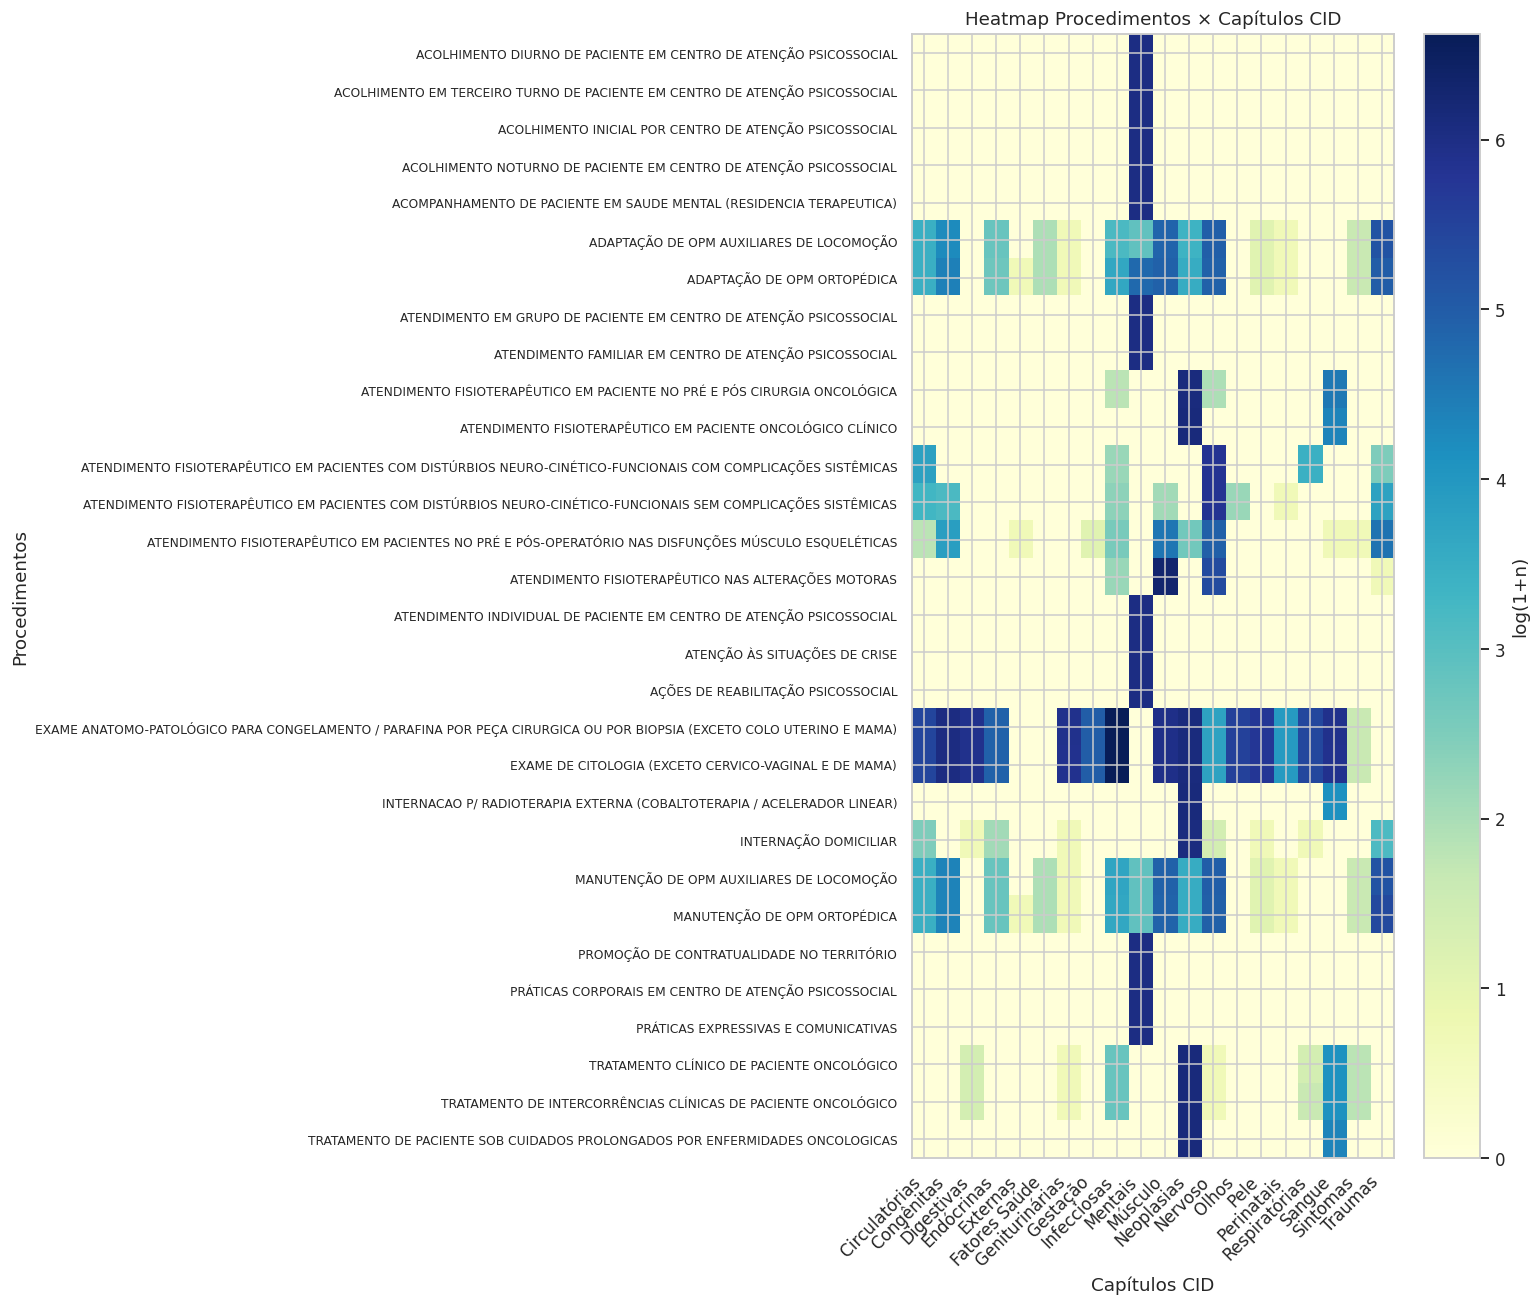

CAPITULO                                            Circulatórias  Congênitas  \
NO_PROCEDIMENTO                                                                 
ACOLHIMENTO DIURNO DE PACIENTE EM CENTRO DE ATE...              0           0   
ACOLHIMENTO EM TERCEIRO TURNO DE PACIENTE EM CE...              0           0   
ACOLHIMENTO INICIAL POR CENTRO DE ATENÇÃO PSICO...              0           0   
ACOLHIMENTO NOTURNO DE PACIENTE EM CENTRO DE AT...              0           0   
ACOMPANHAMENTO DE PACIENTE EM SAUDE MENTAL (RES...              0           0   

CAPITULO                                            Digestivas  Endócrinas  \
NO_PROCEDIMENTO                                                              
ACOLHIMENTO DIURNO DE PACIENTE EM CENTRO DE ATE...           0           0   
ACOLHIMENTO EM TERCEIRO TURNO DE PACIENTE EM CE...           0           0   
ACOLHIMENTO INICIAL POR CENTRO DE ATENÇÃO PSICO...           0           0   
ACOLHIMENTO NOTURNO DE PACIENTE EM CENTRO 

In [ ]:
#####################################
# 1 Ler relação procedimento-CID
#####################################

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10,4,1,6],
    names=[
        "CO_PROCEDIMENTO",
        "CO_CID",
        "ST_PRINCIPAL",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

#####################################
# 2 Ler procedimentos
#####################################

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

#####################################
# 3 Criar capítulos CID
#####################################

def capitulo(cid):

    letra=str(cid)[0]

    mapa={

        'A':'Infecciosas',
        'B':'Infecciosas',
        'C':'Neoplasias',
        'D':'Sangue',
        'E':'Endócrinas',
        'F':'Mentais',
        'G':'Nervoso',
        'H':'Olhos',
        'I':'Circulatórias',
        'J':'Respiratórias',
        'K':'Digestivas',
        'L':'Pele',
        'M':'Músculo',
        'N':'Geniturinárias',
        'O':'Gestação',
        'P':'Perinatais',
        'Q':'Congênitas',
        'R':'Sintomas',
        'S':'Traumas',
        'T':'Traumas',
        'V':'Externas',
        'W':'Externas',
        'X':'Externas',
        'Y':'Externas',
        'Z':'Fatores Saúde'
    }

    return mapa.get(letra,"Outros")


proc_cid["CAPITULO"]=(
    proc_cid["CO_CID"]
    .apply(capitulo)
)

#####################################
# 4 Merge
#####################################

base=(
proc_cid
.merge(

procedimentos[
[
"CO_PROCEDIMENTO",
"NO_PROCEDIMENTO"
]
],
on="CO_PROCEDIMENTO",
how="left"
)
)

#####################################
# 5 Selecionar TOP procedimentos
#####################################

top_proc=(
base
.groupby(
"NO_PROCEDIMENTO"
)
.size()
.sort_values(
ascending=False
)
.head(30)
.index
)

base=base[
base["NO_PROCEDIMENTO"]
.isin(top_proc)
]

#####################################
# 6 Criar matriz
#####################################

heatmap= pd.pivot_table(
base,
index="NO_PROCEDIMENTO",
columns="CAPITULO",
values="CO_CID",
aggfunc="count",
fill_value=0
)

#####################################
# 7 Heatmap
#####################################

plt.figure(
figsize=(14,12)
)
img=plt.imshow(
np.log1p(
heatmap
),
aspect="auto",
cmap="YlGnBu"
)
plt.colorbar(
img,
label="log(1+n)"
)
plt.xticks(
range(
len(
heatmap.columns
)
),
heatmap.columns,
rotation=45,
ha='right'
)
plt.yticks(
range(
len(
heatmap.index
)
),
heatmap.index,
fontsize=8
)
plt.title(
"Heatmap Procedimentos × Capítulos CID"
)
plt.xlabel(
"Capítulos CID"
)
plt.ylabel(
"Procedimentos"
)
plt.tight_layout()
plt.savefig(

"heatmap_procedimentos_capitulos.png",

dpi=300
)
plt.show()

#####################################
# salvar matriz
#####################################

heatmap.to_csv(
"heatmap_procedimentos_capitulos.csv",
encoding="utf-8-sig"
)
print(
heatmap.head()
)

# 5.8 Detectar Procedimentos Orfãos

A lógica para identificar os procedimentos órfãos envolveu os seguintes passos, baseados na análise dos arquivos `tb_procedimento.txt` (que lista todos os procedimentos) e `rl_procedimento_cid.txt` (que contém a relação entre procedimentos e CIDs):

1.  **Leitura dos Dados:** Primeiro, os dois arquivos principais foram lidos em DataFrames separados: `procedimentos` (com todos os detalhes dos procedimentos) e `proc_cid` (com as associações entre códigos de procedimento e códigos CID).

2.  **Limpeza dos Códigos:** Certificou-se que os códigos de procedimento (`CO_PROCEDIMENTO`) e de CID (`CO_CID`) em ambos os DataFrames estavam limpos, removendo espaços em branco extras que poderiam impedir uma comparação correta.

3.  **Identificação de Procedimentos com CID:** Foi criada uma lista de todos os códigos de procedimento (`CO_PROCEDIMENTO`) que aparecem no DataFrame `proc_cid`. Essa lista representa todos os procedimentos que *têm* pelo menos um CID associado.

4.  **Filtragem para Órfãos:** Em seguida, o DataFrame `procedimentos` (que contém *todos* os procedimentos) foi filtrado. Foram selecionados apenas os procedimentos cujos códigos *não* estavam presentes na lista de `procedimentos_com_cid` (ou seja, aqueles que não têm nenhuma associação CID no arquivo `rl_procedimento_cid.txt`).

5.  **Resultado:** O resultado dessa filtragem é o DataFrame `procedimentos_orfaos`, que contém apenas os procedimentos que não possuem nenhum CID associado. As contagens (total de procedimentos, com CID e órfãos) e as primeiras linhas desses procedimentos órfãos foram então exibidas e salvas em um arquivo CSV.

Em resumo, a lógica procura por procedimentos que existem na tabela geral de procedimentos (`tb_procedimento.txt`), mas que não aparecem na tabela de relacionamento (`rl_procedimento_cid.txt`), indicando que não estão vinculados a nenhum diagnóstico CID.

In [ ]:
# ==============================
# 1. Ler procedimentos
# ==============================

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# ==============================
# 2. Ler relação procedimento ↔ CID
# ==============================

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10, 4, 1, 6],
    names=[
        "CO_PROCEDIMENTO",
        "CO_CID",
        "ST_PRINCIPAL",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)

# ==============================
# 3. Limpar códigos
# ==============================

procedimentos["CO_PROCEDIMENTO"] = procedimentos["CO_PROCEDIMENTO"].str.strip()
proc_cid["CO_PROCEDIMENTO"] = proc_cid["CO_PROCEDIMENTO"].str.strip()
proc_cid["CO_CID"] = proc_cid["CO_CID"].str.strip()

# ==============================
# 4. Detectar procedimentos órfãos
#    Procedimentos que não aparecem
#    em rl_procedimento_cid
# ==============================

procedimentos_com_cid = proc_cid["CO_PROCEDIMENTO"].dropna().unique()

procedimentos_orfaos = procedimentos[
    ~procedimentos["CO_PROCEDIMENTO"].isin(procedimentos_com_cid)
].copy()

# ==============================
# 5. Resultado
# ==============================

print("Total de procedimentos:", procedimentos["CO_PROCEDIMENTO"].nunique())
print("Procedimentos com CID:", len(procedimentos_com_cid))
print("Procedimentos órfãos:", procedimentos_orfaos["CO_PROCEDIMENTO"].nunique())

print(procedimentos_orfaos[
    [
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "DT_COMPETENCIA"
    ]
].head(50))

# ==============================
# 6. Salvar CSV
# ==============================

procedimentos_orfaos.to_csv(
    "procedimentos_orfaos_sem_cid.csv",
    index=False,
    encoding="utf-8-sig"
)

Total de procedimentos: 4984
Procedimentos com CID: 2896
Procedimentos órfãos: 2088
   CO_PROCEDIMENTO                                    NO_PROCEDIMENTO  \
0       0101010010  ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...   
1       0101010028  ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...   
2       0101010036       PRÁTICA CORPORAL / ATIVIDADE FÍSICA EM GRUPO   
3       0101010095                  PREVENÇÃO DA COVID-19 NAS ESCOLAS   
4       0101010109  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
5       0101010117  ATIVIDADE DE EDUCAÇÃO PERMANENTE EM SAÚDE DO T...   
6       0101010125  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
7       0101010133  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
8       0101010141  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
9       0101010150  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
10      0101010168  ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...   
11      0101010176  ATIVIDADES EDUCATIVA

# 6. Análise Avançada

In [ ]:
df.describe(include="all")

,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID,QT_PALAVRAS_PROCEDIMENTO,TP_COMPLEXIDADE,complexidade,qtd_caracteres,qtd_termos_tecnicos,possui_sigla,possui_abreviacao
count,81864,81864,81864,81864,81864,81864,81864.000000,81864,71683,81864.000000,81864.000000,81864.000000,81864.000000
unique,2896,8205,2,1,2895,8194,NaN,4,3,NaN,NaN,NaN,NaN
top,0203020030,B92,S,202605,EXAME ANATOMO-PATOLÓGICO PARA CONGELAMENTO / P...,Seqüelas de hanseníase [lepra],NaN,2,Média Complexidade,NaN,NaN,NaN,NaN
freq,4448,162,81502,81864,4448,162,NaN,44937,44937,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,8.148844,NaN,NaN,60.572682,4.942771,0.999401,0.000611
std,NaN,NaN,NaN,NaN,NaN,NaN,3.896091,NaN,NaN,26.858482,2.958411,0.024458,0.024706
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,8.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,41.000000,3.000000,1.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,56.000000,5.000000,1.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,73.000000,6.000000,1.000000,0.000000


# 6.1 Distribuição  da complexidade

### Lógica para Calcular a Complexidade

A complexidade dos procedimentos neste projeto é determinada a partir de um campo já existente nos dados de origem do SIGTAP (`tb_procedimento.txt`), chamado `TP_COMPLEXIDADE`. Este campo é um código numérico que o próprio sistema do SUS utiliza para classificar o tipo de complexidade. A lógica de cálculo aplicada no notebook é, na verdade, uma *tradução* ou *mapeamento* desses códigos para termos mais descritivos e compreensíveis:

*   **Código `1`**: Mapeado para "Atenção Básica"
*   **Código `2`**: Mapeado para "Média Complexidade"
*   **Código `3`**: Mapeado para "Alta Complexidade"

Portanto, a coluna `complexidade` no DataFrame `df` e a coluna `COMPLEXIDADE` no DataFrame `procedimentos` não são resultados de um cálculo algorítmico baseado nos atributos textuais (`QT_PALAVRAS_PROCEDIMENTO`, `qtd_termos_tecnicos`, etc.) neste estágio inicial. Elas representam a complexidade **já classificada na fonte de dados do SIGTAP**. Posteriormente, esses atributos textuais são usados para *modelar e interpretar* como eles se relacionam com essa complexidade predefinida, como visto na análise da árvore de decisão.

In [ ]:
PALETA = {"Atenção Básica": "#4C9F70", "Média Complexidade": "#E1A100", "Alta Complexidade": "#C44E52"}
ORDEM = ["Atenção Básica", "Média Complexidade", "Alta Complexidade"]

# Calculate distribution of complexity
# Mapear complexidade
mapa_complexidade = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}

procedimentos["COMPLEXIDADE"] = procedimentos["TP_COMPLEXIDADE"].map(mapa_complexidade)

dist_complexidade = (
    procedimentos
    .groupby('COMPLEXIDADE')
    .size()
    .reset_index(name='QT_PROCEDIMENTOS')
)
dist_complexidade['PERCENTUAL'] = (dist_complexidade['QT_PROCEDIMENTOS'] / dist_complexidade['QT_PROCEDIMENTOS'].sum() * 100).round(1)

# Define colors based on the global PALETA and ORDER
# Filter out colors for categories not present in dist_complexidade if necessary,
# though in this case, all categories should be present.
colors = [PALETA[c] for c in ORDEM if c in dist_complexidade['COMPLEXIDADE'].values]

print("Distribuição da Complexidade:")
print(dist_complexidade)

Distribuição da Complexidade:
         COMPLEXIDADE  QT_PROCEDIMENTOS  PERCENTUAL
0   Alta Complexidade              1639        37.9
1      Atenção Básica               237         5.5
2  Média Complexidade              2451        56.6


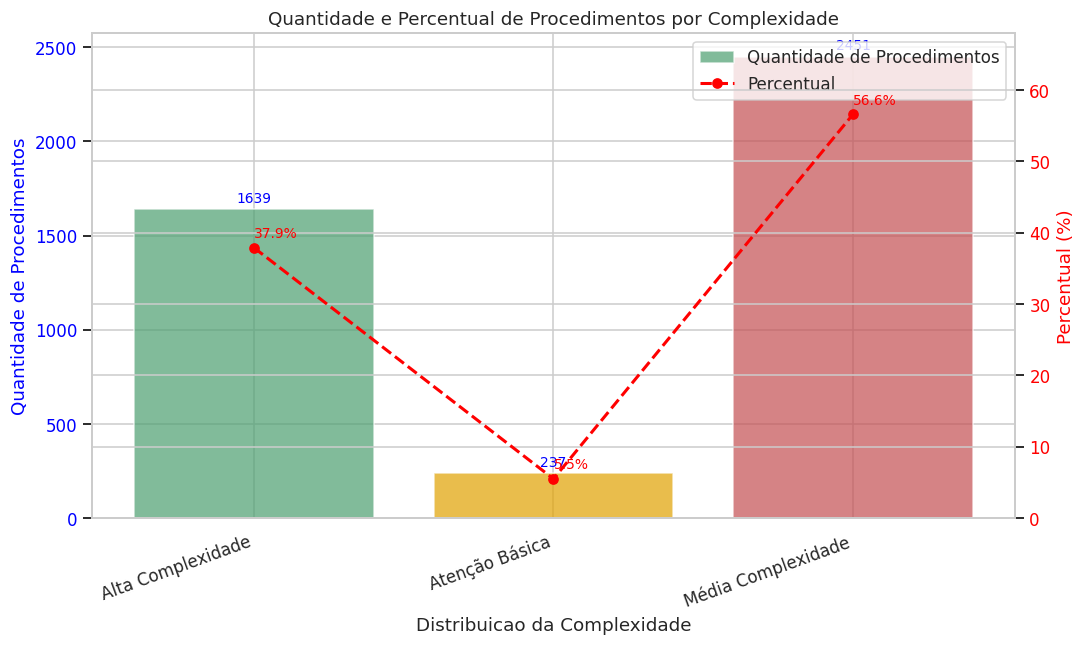

In [ ]:
import matplotlib.ticker as mticker

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for Quantity on ax1
ax1.bar(dist_complexidade["COMPLEXIDADE"],
        dist_complexidade["QT_PROCEDIMENTOS"],
        color=colors,  # Using the colors defined previously
        alpha=0.7,
        label="Quantidade de Procedimentos")

ax1.set_xlabel("Distribuicao da Complexidade")
ax1.set_ylabel("Quantidade de Procedimentos", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title("Quantidade e Percentual de Procedimentos por Complexidade")
ax1.set_xticks(range(len(dist_complexidade["COMPLEXIDADE"]))) # Set integer ticks for x-axis
ax1.set_xticklabels(dist_complexidade["COMPLEXIDADE"], rotation=20, ha='right')

# Add quantity labels on top of the bars
for i, valor in enumerate(dist_complexidade["QT_PROCEDIMENTOS"]):
    ax1.text(i, valor + 20, str(valor), ha='center', va='bottom', fontsize=9, color='blue')

# Create a second y-axis for Percentage
ax2 = ax1.twinx()
ax2.plot(dist_complexidade["COMPLEXIDADE"],
         dist_complexidade["PERCENTUAL"],
         color='red',
         marker='o',
         linestyle='--',
         linewidth=2,
         label="Percentual")

ax2.set_ylabel("Percentual (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, dist_complexidade["PERCENTUAL"].max() * 1.2) # Adjust y-limit for percentage

# Add percentage labels next to the line markers
for i, valor in enumerate(dist_complexidade["PERCENTUAL"]):
    ax2.text(i, valor + 1, f'{valor:.1f}%', ha='left', va='bottom', fontsize=9, color='red')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig("quantidade_percentual_complexidade_procedimentos.png", dpi=300)
plt.show()

# 6.2 Complexidade dos Capitulos do CID-10 x SIGTAB


=== CID-10 x SIGTAP: Procedimentos por Complexidade ===
COMPLEXIDADE_SIGTAP             Alta Complexidade  Atenção Básica  \
CAPITULO_CID10                                                      
I - Infecciosas e parasitárias                133              12   
II - Neoplasias                               495               0   
III - Sangue/imunidade                        260               0   
IV - Endócrinas/metabólicas                   174               0   
IX - Circulatórias                            202               0   
Outros                                          0               0   
V - Transtornos mentais                        41               2   
VI - Sistema nervoso                          199               1   
VII/VIII - Olhos/ouvidos                       64               1   
X - Respiratórias                              61               0   
XI - Digestivas                                80               0   
XII - Pele                                    

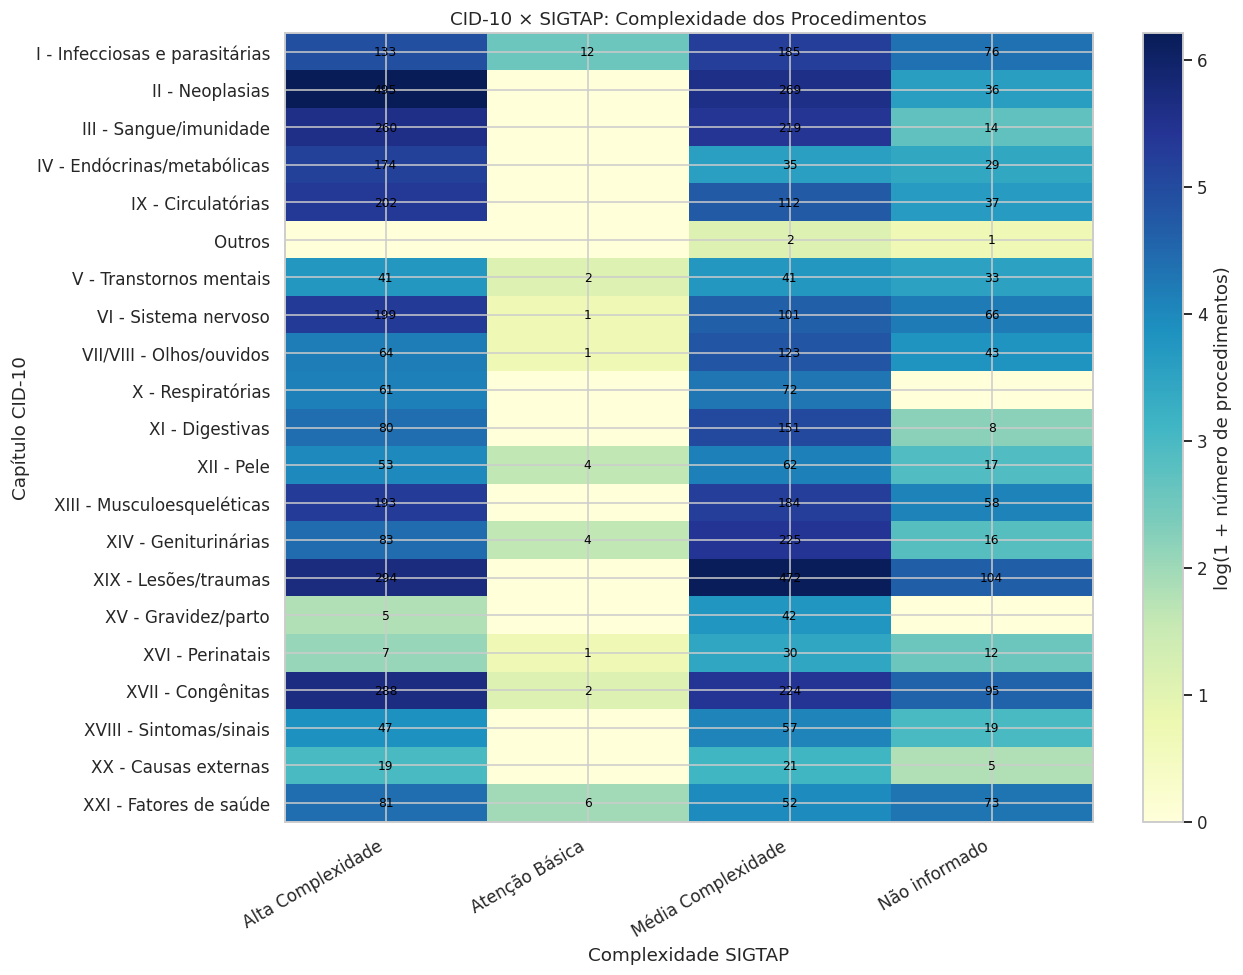

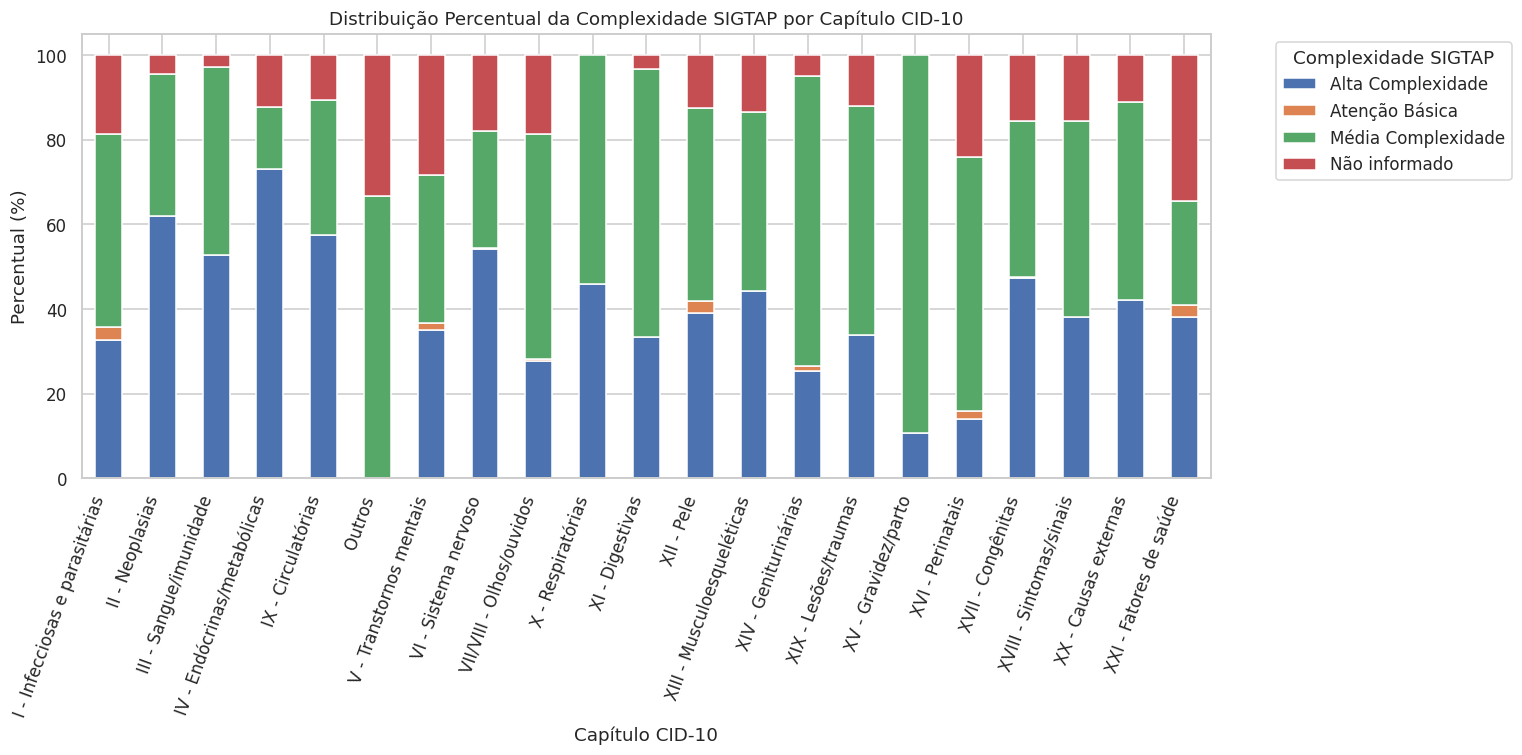

In [ ]:
# ==============================
# 1. Ler relação Procedimento ↔ CID
# Fonte: SIGTAP
# ==============================

proc_cid = pd.read_fwf(
    "rl_procedimento_cid.txt",
    widths=[10, 4, 1, 6],
    names=["CO_PROCEDIMENTO", "CO_CID", "ST_PRINCIPAL", "DT_COMPETENCIA"],
    dtype=str,
    encoding='latin-1' # Added encoding
)

# ==============================
# 2. Ler procedimentos
# Fonte: SIGTAP
# ==============================

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1' # Added encoding
)

# ==============================
# 3. Criar capítulos CID-10
# Fonte: CID-10
# ==============================

def capitulo_cid10(cid):
    if pd.isna(cid):
        return "Sem CID"

    cid = str(cid).strip()

    if len(cid) == 0:
        return "Sem CID"

    letra = cid[0]

    mapa = {
        "A": "I - Infecciosas e parasitárias",
        "B": "I - Infecciosas e parasitárias",
        "C": "II - Neoplasias",
        "D": "III - Sangue/imunidade",
        "E": "IV - Endócrinas/metabólicas",
        "F": "V - Transtornos mentais",
        "G": "VI - Sistema nervoso",
        "H": "VII/VIII - Olhos/ouvidos",
        "I": "IX - Circulatórias",
        "J": "X - Respiratórias",
        "K": "XI - Digestivas",
        "L": "XII - Pele",
        "M": "XIII - Musculoesqueléticas",
        "N": "XIV - Geniturinárias",
        "O": "XV - Gravidez/parto",
        "P": "XVI - Perinatais",
        "Q": "XVII - Congênitas",
        "R": "XVIII - Sintomas/sinais",
        "S": "XIX - Lesões/traumas",
        "T": "XIX - Lesões/traumas",
        "V": "XX - Causas externas",
        "W": "XX - Causas externas",
        "X": "XX - Causas externas",
        "Y": "XX - Causas externas",
        "Z": "XXI - Fatores de saúde"
    }

    return mapa.get(letra, "Outros")


proc_cid["CAPITULO_CID10"] = proc_cid["CO_CID"].apply(capitulo_cid10)

# ==============================
# 4. Mapear complexidade SIGTAP
# ==============================

mapa_complexidade = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}

procedimentos["COMPLEXIDADE_SIGTAP"] = (
    procedimentos["TP_COMPLEXIDADE"]
    .str.strip()
    .map(mapa_complexidade)
    .fillna("Não informado")
)

# ==============================
# 5. Merge CID-10 × SIGTAP
# ==============================

base = proc_cid.merge(
    procedimentos[
        [
            "CO_PROCEDIMENTO",
            "NO_PROCEDIMENTO",
            "TP_COMPLEXIDADE",
            "COMPLEXIDADE_SIGTAP"
        ]
    ],
    on="CO_PROCEDIMENTO",
    how="left"
)

# ==============================
# 6. Tabela: Capítulo CID-10 × Complexidade SIGTAP
# ==============================

cid10_x_sigtap_complexidade = pd.pivot_table(
    base,
    index="CAPITULO_CID10",
    columns="COMPLEXIDADE_SIGTAP",
    values="CO_PROCEDIMENTO",
    aggfunc=pd.Series.nunique,
    fill_value=0
)

print("\n=== CID-10 x SIGTAP: Procedimentos por Complexidade ===")
print(cid10_x_sigtap_complexidade)

cid10_x_sigtap_complexidade.to_csv(
    "cid10_x_sigtap_complexidade.csv",
    encoding="utf-8-sig"
)

# ==============================
# 7. Percentual por capítulo CID-10
# ==============================

percentual_por_capitulo = (
    cid10_x_sigtap_complexidade
    .div(cid10_x_sigtap_complexidade.sum(axis=1), axis=0)
    .fillna(0)
    * 100
).round(2)

print("\n=== Percentual de Complexidade dentro de cada Capítulo CID-10 ===")
print(percentual_por_capitulo)

percentual_por_capitulo.to_csv(
    "cid10_x_sigtap_complexidade_percentual.csv",
    encoding="utf-8-sig"
)

# ==============================
# 8. Heatmap absoluto
# ==============================

plt.figure(figsize=(12, 9))

img = plt.imshow(
    np.log1p(cid10_x_sigtap_complexidade),
    aspect="auto",
    cmap="YlGnBu"
)

plt.colorbar(img, label="log(1 + número de procedimentos)")

plt.xticks(
    range(len(cid10_x_sigtap_complexidade.columns)),
    cid10_x_sigtap_complexidade.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(cid10_x_sigtap_complexidade.index)),
    cid10_x_sigtap_complexidade.index
)

for i in range(len(cid10_x_sigtap_complexidade.index)):
    for j in range(len(cid10_x_sigtap_complexidade.columns)):
        valor = cid10_x_sigtap_complexidade.iloc[i, j]
        if valor > 0:
            plt.text(
                j,
                i,
                str(valor),
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

plt.title("CID-10 × SIGTAP: Complexidade dos Procedimentos")
plt.xlabel("Complexidade SIGTAP")
plt.ylabel("Capítulo CID-10")
plt.tight_layout()
plt.savefig("heatmap_cid10_x_sigtap_complexidade.png", dpi=300)
plt.show()

# ==============================
# 9. Gráfico percentual empilhado
# ==============================

percentual_por_capitulo.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Distribuição Percentual da Complexidade SIGTAP por Capítulo CID-10")
plt.xlabel("Capítulo CID-10")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=70, ha="right")
plt.legend(title="Complexidade SIGTAP", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("percentual_complexidade_sigtap_por_capitulo_cid10.png", dpi=300)
plt.show()

# ==============================
# 10. Salvar base analítica
# ==============================

base.to_csv(
    "base_cid10_x_sigtap_complexidade.csv",
    index=False,
    encoding="utf-8-sig"
)


# Salvando o dataset atualizado CID_Consolidado.csv

In [ ]:
# Definindo o caminho completo para salvar o arquivo CSV no Google Drive, incluindo os novos tse_x e tse_y
output_file_path = '/content/CID_Consolidado.csv'

# Salvando o DataFrame atualizado em um novo arquivo CSV, sem o índice do pandas
df.to_csv(output_file_path, index=False)

print(f"✅ DataFrame 'df' atualizado e salvo com sucesso em: {output_file_path}")

✅ DataFrame 'df' atualizado e salvo com sucesso em: /content/CID_Consolidado.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CO_PROCEDIMENTO           81864 non-null  object
 1   CO_CID                    81864 non-null  object
 2   ST_PRINCIPAL              81864 non-null  object
 3   DT_COMPETENCIA            81864 non-null  object
 4   NO_PROCEDIMENTO           81864 non-null  object
 5   NO_CID                    81864 non-null  object
 6   QT_PALAVRAS_PROCEDIMENTO  81864 non-null  int64 
 7   TP_COMPLEXIDADE           81864 non-null  object
 8   complexidade              71683 non-null  object
 9   qtd_caracteres            81864 non-null  int64 
 10  qtd_termos_tecnicos       81864 non-null  int64 
 11  possui_sigla              81864 non-null  int64 
 12  possui_abreviacao         81864 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 8.1+ MB


## 6.1 Acrescentar a coluna complexidade dos procedimentos no dataset

In [ ]:
import re

# Re-initialize df from 'resultado' to ensure a clean state before adding features
# This assumes 'resultado' DataFrame is available and represents the merged data from step 4
df = resultado.copy()

# Add QT_PALAVRAS_PROCEDIMENTO if not already present or to ensure it's up-to-date
if 'QT_PALAVRAS_PROCEDIMENTO' not in df.columns:
    df['QT_PALAVRAS_PROCEDIMENTO'] = df['NO_PROCEDIMENTO'].apply(lambda x: len(str(x).split()))

# Merge TP_COMPLEXIDADE from 'procedimentos' into 'df'
# Avoid suffix issues by dropping any existing TP_COMPLEXIDADE related columns
# and then performing a clean merge.
conflicting_tp_cols = [col for col in df.columns if 'TP_COMPLEXIDADE' in col]
if conflicting_tp_cols:
    df = df.drop(columns=conflicting_tp_cols, errors='ignore')
df = df.merge(
    procedimentos[['CO_PROCEDIMENTO', 'TP_COMPLEXIDADE']],
    on='CO_PROCEDIMENTO',
    how='left'
)

# Mapear TP_COMPLEXIDADE para a coluna 'complexidade' em 'df'
mapa_complexidade = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}
df["complexidade"] = df["TP_COMPLEXIDADE"].map(mapa_complexidade)

# Calcular qtd_caracteres
df['qtd_caracteres'] = df['NO_PROCEDIMENTO'].apply(lambda x: len(str(x)))

# Funções para calcular termos técnicos, siglas e abreviações
def count_technical_terms(text):
    technical_term_pattern = r'\b[A-Z]{3,}\b|\b\w+\d+\w*\b'
    return len(re.findall(technical_term_pattern, str(text)))

def has_acronym(text):
    acronym_pattern = r'\b[A-Z]{2,}\b'
    return 1 if re.search(acronym_pattern, str(text)) else 0

def has_abbreviation(text):
    abbreviation_pattern = r'\b\w+\.\b'
    return 1 if re.search(abbreviation_pattern, str(text).lower()) else 0

df['qtd_termos_tecnicos'] = df['NO_PROCEDIMENTO'].apply(count_technical_terms)
df['possui_sigla'] = df['NO_PROCEDIMENTO'].apply(has_acronym)
df['possui_abreviacao'] = df['NO_PROCEDIMENTO'].apply(has_abbreviation)

print("DataFrame 'df' enriquecido com colunas de complexidade e atributos textuais.")
display(df.head())
display(df.info())

DataFrame 'df' enriquecido com colunas de complexidade e atributos textuais.


,CO_PROCEDIMENTO,CO_CID,ST_PRINCIPAL,DT_COMPETENCIA,NO_PROCEDIMENTO,NO_CID,QT_PALAVRAS_PROCEDIMENTO,TP_COMPLEXIDADE,complexidade,qtd_caracteres,qtd_termos_tecnicos,possui_sigla,possui_abreviacao
0,0201010038,C73,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia maligna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
1,0201010038,D093,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Carcinoma in situ da tireóide e de outras glân...,4,2,Média Complexidade,29,3,1,0
2,0201010038,D34,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia benigna da glândula tireóide,4,2,Média Complexidade,29,3,1,0
3,0201010038,D440,S,202605,BIOPSIA CIRURGICA DE TIREOIDE,Neoplasia de comportamento incerto ou desconhe...,4,2,Média Complexidade,29,3,1,0
4,0201010046,C211,S,202605,BIOPSIA DE ANUS E CANAL ANAL,Neoplasia maligna do canal anal,6,2,Média Complexidade,28,4,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81864 entries, 0 to 81863
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   CO_PROCEDIMENTO           81864 non-null  object
 1   CO_CID                    81864 non-null  object
 2   ST_PRINCIPAL              81864 non-null  object
 3   DT_COMPETENCIA            81864 non-null  object
 4   NO_PROCEDIMENTO           81864 non-null  object
 5   NO_CID                    81864 non-null  object
 6   QT_PALAVRAS_PROCEDIMENTO  81864 non-null  int64 
 7   TP_COMPLEXIDADE           81864 non-null  object
 8   complexidade              71683 non-null  object
 9   qtd_caracteres            81864 non-null  int64 
 10  qtd_termos_tecnicos       81864 non-null  int64 
 11  possui_sigla              81864 non-null  int64 
 12  possui_abreviacao         81864 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 8.1+ MB


None

# 6.2 Histogramas Individuais

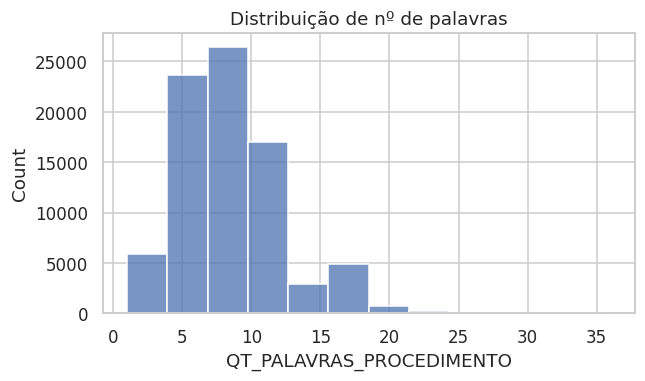

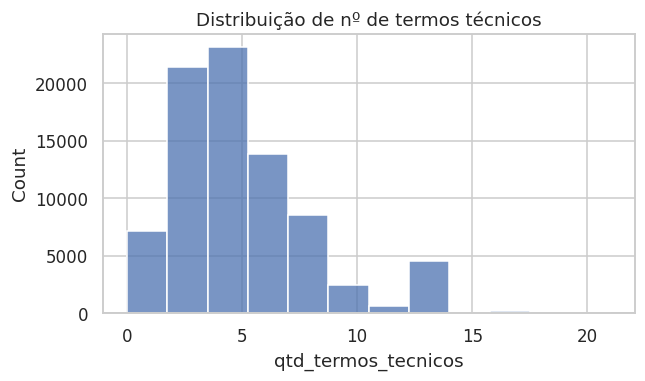

In [ ]:
# Histogramas dos principais atributos (gráficos individuais)
for col, titulo in [("QT_PALAVRAS_PROCEDIMENTO","Distribuição de nº de palavras"),
                    ("qtd_termos_tecnicos","Distribuição de nº de termos técnicos")]:
    fig, ax = plt.subplots(figsize=(6,3.6))
    sns.histplot(df[col], bins=12, color="#4C72B0", ax=ax)
    ax.set_title(titulo)
    plt.tight_layout(); plt.savefig(f"fig_hist_{col}.png", bbox_inches="tight"); plt.show()

### Por que escolhemos esses histogramas?

Os histogramas para `QT_PALAVRAS_PROCEDIMENTO` (quantidade de palavras no procedimento) e `qtd_termos_tecnicos` (quantidade de termos técnicos) foram escolhidos por serem **atributos chave** na sua definição heurística de complexidade. A visualização da distribuição desses atributos é fundamental por vários motivos:

1.  **Entendimento da Composição do Dados:** Eles nos permitem ver rapidamente como esses valores se distribuem. Por exemplo, a maioria dos procedimentos tem poucas palavras? Existem muitos procedimentos com uma alta densidade de termos técnicos? Isso ajuda a construir uma intuição sobre o dataset.
2.  **Identificação de Padrões:** Podemos observar se as distribuições são simétricas, assimétricas, ou se há múltiplos picos, o que pode indicar diferentes 'tipos' de procedimentos dentro do mesmo atributo.
3.  **Base para Análise de Outliers:** Antes de identificar *outliers* usando métodos como o IQR (que já foi feito na seção seguinte), é crucial entender a distribuição geral. Um valor que é um *outlier* em uma distribuição normal pode ser um valor comum em uma distribuição assimétrica. Os histogramas fornecem esse contexto visual.
4.  **Validação das Heurísticas:** Como a complexidade é definida por regras heurísticas que usam esses atributos, entender a distribuição individual de `QT_PALAVRAS_PROCEDIMENTO` e `qtd_termos_tecnicos` ajuda a validar se as faixas de valores consideradas para 'baixa', 'média' e 'alta' complexidade fazem sentido em relação à realidade dos dados.

# 6.3 Análise de Outliers
*Outliers* (descrições muito curtas/longas, procedimentos raros, alto nº de termos técnicos) são
identificados por *boxplots* e pela regra do **IQR**. **A remoção não é automática**: valores
extremos podem representar informação clinicamente relevante.

Por que analisar os Outliers?
Identificação de Erros de Dados: Muitos outliers podem ser resultado de erros de digitação, erros de medição ou problemas na coleta de dados. Analisá-los permite identificar e corrigir essas inconsistências, melhorando a qualidade geral do dataset.

Descoberta de Eventos Raros, mas Legítimos: Nem todo valor atípico é um erro. Em dados médicos, um outlier pode representar um caso raro, uma condição incomum ou um procedimento de alta complexidade que, embora raro, é clinicamente legítimo e importante. Removê-los sem análise pode levar à perda de informações valiosas ou à subestimação de riscos/eventos importantes.

Melhor Compreensão do Domínio: Ao investigar os outliers, você pode obter insights profundos sobre o domínio em questão. Por exemplo, um procedimento com um número extremamente alto de palavras ou termos técnicos pode indicar uma especificidade linguística que merece atenção especial na simplificação de textos médicos.

Decisões Mais Informadas sobre o Tratamento: A análise dos outliers informa se eles devem ser removidos, transformados (por exemplo, por meio de winsorization ou log transformation), ou se devem ser tratados como uma categoria à parte. A decisão dependerá do contexto e do objetivo da sua análise ou modelo. Ignorar essa análise pode levar a tratamentos inadequados que prejudicam a representatividade dos dados.

Impacto na Modelagem: Mesmo que você decida remover ou tratar outliers para melhorar o desempenho de um modelo, a análise prévia ajuda a justificar essa decisão e a entender o impacto que esses valores teriam se não fossem tratados. Isso é fundamental para a interpretabilidade e a robustez dos seus resultados.

No seu caso, por exemplo, analisar os procedimentos com outliers em QT_PALAVRAS_PROCEDIMENTO, qtd_caracteres ou qtd_termos_tecnicos pode revelar:

Erros: Algumas descrições podem ter sido inseridas incorretamente.
Procedimentos Altamente Específicos/Raros: Descrições excepcionalmente longas ou com muitos termos técnicos podem pertencer a procedimentos de alta complexidade que são naturalmente mais detalhados ou raros.
Necessidades de Simplificação Específicas: Outliers que representam procedimentos legítimos, mas linguisticamente muito complexos, podem ser os primeiros alvos do projeto Traduz Saúde para simplificação.

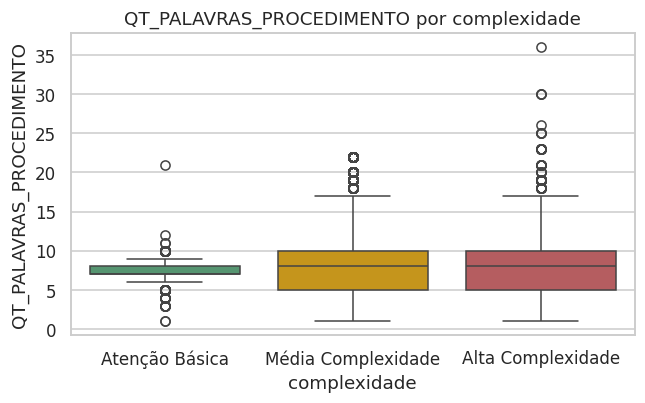

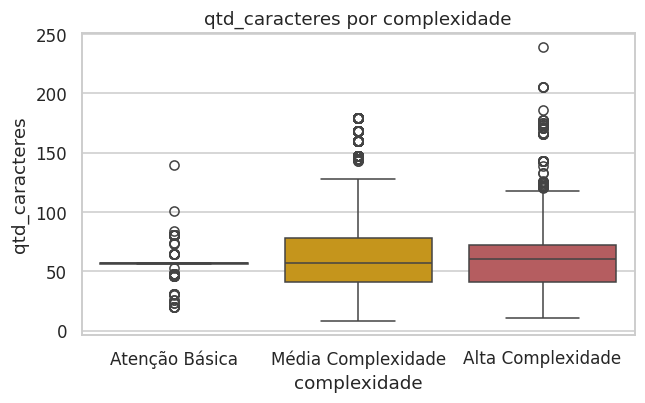

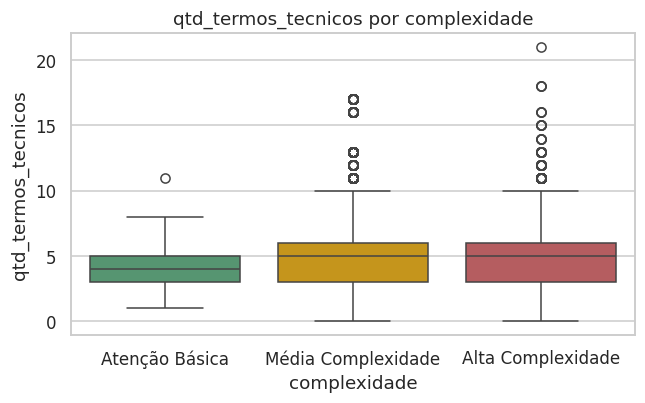

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is also imported if used directly

# Boxplots por complexidade (gráficos individuais)
for col in ["QT_PALAVRAS_PROCEDIMENTO","qtd_caracteres","qtd_termos_tecnicos"]:
    fig, ax = plt.subplots(figsize=(6,3.8))
    sns.boxplot(data=df, x="complexidade", y=col, order=ORDEM,
                palette=PALETA, ax=ax)
    ax.set_title(f"{col} por complexidade")
    plt.tight_layout(); plt.savefig(f"fig_box_{col}.png", bbox_inches="tight"); plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

Seaborn version: 0.13.2
Matplotlib version: 3.10.0


# 6.4 Remoção de Outliers

Remover outliers pode ser benéfico por várias razões:

Melhorar a performance de modelos: Muitos algoritmos de machine learning (como regressão linear, redes neurais, etc.) são sensíveis a outliers. Valores extremos podem distorcer o treinamento do modelo, levando a previsões menos precisas e a um desempenho geral inferior. Ao remover ou tratar os outliers, o modelo pode aprender padrões mais representativos da maioria dos dados.

Reduzir viés e aumentar a precisão de estimativas: Outliers podem inflacionar ou deflacionar métricas estatísticas como a média e o desvio padrão. Por exemplo, em uma análise de salários, um ou dois salários extremamente altos podem fazer com que a média pareça muito maior do que a realidade da maioria dos funcionários. Ao removê-los, as estatísticas descritivas se tornam mais representativas do comportamento típico dos dados.

Identificar erros nos dados: Às vezes, um outlier não é um valor real, mas um erro de digitação, um erro de medição ou um problema na coleta de dados. A identificação de outliers pode ser o primeiro passo para encontrar e corrigir esses erros, o que melhora a qualidade geral do seu conjunto de dados.

Aumentar a interpretabilidade: Em alguns casos, a presença de outliers pode dificultar a compreensão dos padrões subjacentes nos dados. Remover esses valores extremos pode tornar as distribuições mais claras e as relações entre as variáveis mais evidentes, facilitando a interpretação dos resultados.

Atender a suposições de testes estatísticos: Muitos testes estatísticos e modelos pressupõem que os dados seguem uma distribuição normal ou que não há valores extremos. A presença de outliers pode violar essas suposições, invalidando os resultados dos testes e as inferências feitas.

É importante notar que a remoção de outliers deve ser feita com cautela. Nem todo valor atípico é um erro; alguns podem representar eventos raros, mas legítimos, que carregam informações importantes. A decisão de remover ou tratar outliers depende muito do contexto do problema, do conhecimento do domínio e do impacto que esses valores têm sobre a análise que você pretende fazer.

Neste caso, por exemplo, os boxplots que geramos mostram esses outliers, permitindo que você visualize onde esses valores extremos estão e decida se eles devem ser tratados para a próxima etapa de modelagem ou análise.

In [ ]:
# Identificação (não remoção) de outliers por IQR
def outliers_iqr(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3-q1
    return s[(s < q1-1.5*iqr) | (s > q3+1.5*iqr)]
for col in ["QT_PALAVRAS_PROCEDIMENTO","qtd_caracteres","qtd_termos_tecnicos"]:
    out = outliers_iqr(df[col])
    print(f"{col}: {len(out)} outlier(s)")
df.loc[outliers_iqr(df["QT_PALAVRAS_PROCEDIMENTO"]).index, ["NO_PROCEDIMENTO","QT_PALAVRAS_PROCEDIMENTO"]]

QT_PALAVRAS_PROCEDIMENTO: 1137 outlier(s)
qtd_caracteres: 869 outlier(s)
qtd_termos_tecnicos: 5345 outlier(s)


,NO_PROCEDIMENTO,QT_PALAVRAS_PROCEDIMENTO
10913,TESTE IMUNOCROMATOGRÁFICO RÁPIDO PARA DETECÇÃO...,21
18711,ACOMPANHAMENTO DE PESSOAS COM NECESSIDADES DEC...,22
18712,ACOMPANHAMENTO DE PESSOAS COM NECESSIDADES DEC...,22
18713,ACOMPANHAMENTO DE PESSOAS COM NECESSIDADES DEC...,22
18714,ACOMPANHAMENTO DE PESSOAS COM NECESSIDADES DEC...,22
...,...,...
81859,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,20
81860,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,20
81861,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,20
81862,OCI - GIN3 - PROGRESSÃO DA AVALIAÇÃO DIAGNÓSTI...,20


## 6.5 Tarefa preditiva — Árvore de Decisão

Treina‑se uma árvore de decisão para **interpretar** quais atributos mais influenciam a
complexidade. Divisão treino/teste estratificada (70/30) e validação cruzada (3 *folds*).

Treinar uma árvore de decisão é uma excelente escolha para este projeto por várias razões importantes, especialmente considerando o seu objetivo de **interpretar** quais atributos influenciam a complexidade:

1.  **Interpretabilidade (Explicabilidade):** Esta é a principal vantagem de uma árvore de decisão. Ao contrário de modelos mais complexos ('caixas pretas'), uma árvore de decisão pode ser facilmente visualizada e compreendida por humanos. Ela mostra exatamente as regras e os caminhos que levaram a uma classificação específica. Para o seu projeto, onde o objetivo é 'interpretar quais atributos mais influenciam a complexidade', isso é fundamental. Você poderá ver, por exemplo, que se o `QT_PALAVRAS_PROCEDIMENTO` é maior que X e `qtd_termos_tecnicos` é maior que Y, então a complexidade é Alta.

2.  **Lida com Dados Categóricos e Numéricos:** As árvores de decisão conseguem lidar com ambos os tipos de dados (como `QT_PALAVRAS_PROCEDIMENTO` que é numérico e `complexidade` que é categórica) sem a necessidade de uma extensa pré-processamento como, por exemplo, a normalização.

3.  **Não Linearidade:** Ela pode capturar relações não lineares entre as características e a variável alvo, o que é comum em dados do mundo real, como os dados de saúde.

4.  **Seleção de Atributos (Feature Importance):** Automaticamente, as árvores de decisão revelam quais atributos são mais importantes para a classificação, como você já observou nas saídas anteriores (`qtd_caracteres`, `QT_PALAVRAS_PROCEDIMENTO`, `qtd_termos_tecnicos`). Isso ajuda a focar nos fatores mais relevantes.

5.  **Relevância para Heurísticas:** Dada que a sua variável-alvo (`complexidade`) foi definida por regras heurísticas, a árvore de decisão é particularmente útil. Ela pode 'aprender' e representar essas mesmas regras ou variações delas de forma explícita, servindo como uma validação e uma forma de codificar essas heurísticas de maneira algorítmica.

No contexto do seu projeto **Traduz Saúde**, a capacidade de ver claramente as regras que definem a complexidade (por exemplo, "se o número de palavras for maior que X e o número de termos técnicos for maior que Y, então o procedimento é de Alta Complexidade") é extremamente valiosa para a tomada de decisões sobre quais textos priorizar para simplificação.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

RANDOM_STATE = 42

FEATS = ["QT_PALAVRAS_PROCEDIMENTO","qtd_caracteres","qtd_termos_tecnicos","possui_sigla","possui_abreviacao"]
X, y = df[FEATS], df["complexidade"].astype(str)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

acc = accuracy_score(yte, pred)
cv = cross_val_score(clf, X, y, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE))
print(f"Acurácia (teste): {acc:.3f}")
print(f"Acurácia média (CV 3-fold): {cv.mean():.3f} (+/- {cv.std():.3f})")

Acurácia (teste): 0.606
Acurácia média (CV 3-fold): 0.605 (+/- 0.002)


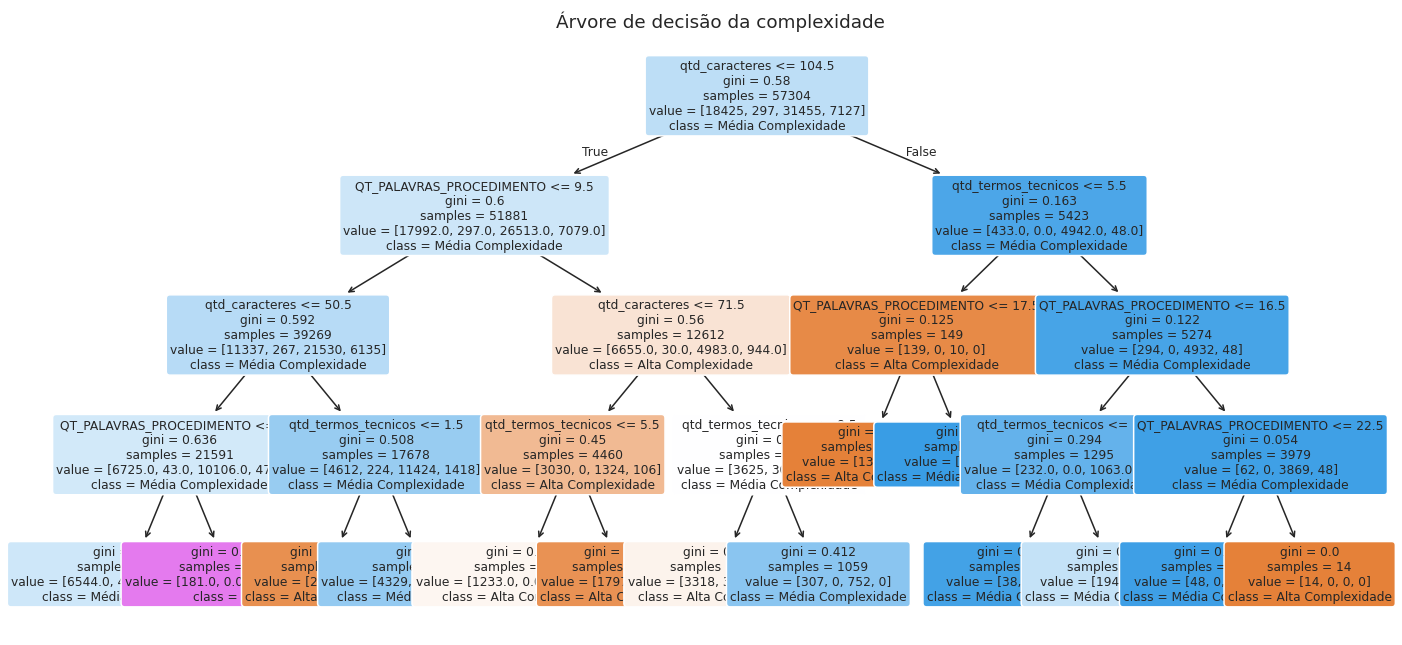

In [ ]:
from sklearn.tree import plot_tree

# Visualização da árvore
fig, ax = plt.subplots(figsize=(13,6))
plot_tree(clf, feature_names=FEATS, class_names=clf.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Árvore de decisão da complexidade")
plt.tight_layout(); plt.savefig("fig_arvore.png", bbox_inches="tight"); plt.show()

# 6.6 Importância dos Atributos

É muito importante verificar a importância dos atributos (ou features) após treinar uma árvore de decisão no seu projeto de classificação da complexidade. Aqui estão os principais motivos:

Interpretabilidade e Entendimento do Modelo: A principal vantagem é entender como a árvore de decisão chegou às suas classificações. Ao saber quais atributos são mais importantes, você pode ver quais fatores são mais decisivos para determinar se um procedimento é de 'Baixa', 'Média' ou 'Alta Complexidade'. Por exemplo, se 'QT_PALAVRAS_PROCEDIMENTO' (quantidade de palavras no procedimento) e 'qtd_termos_tecnicos' (quantidade de termos técnicos) aparecem como os mais importantes, isso valida a sua hipótese de que a extensão e a densidade técnica influenciam a complexidade.

Validação de Hipóteses: No seu caso, a variável complexidade foi criada por regras heurísticas. A importância dos atributos permite que você valide se as características que você acreditava serem relevantes para definir a complexidade (como o número de palavras ou termos técnicos) realmente são as que o modelo está utilizando com mais peso. Se o modelo atribui alta importância a algo inesperado, pode ser um indicativo para investigar mais a fundo ou refinar suas heurísticas.

Seleção de Atributos (Feature Selection): Conhecer a importância dos atributos pode ajudar a simplificar futuros modelos. Se alguns atributos têm importância muito baixa (próxima de zero), você pode considerar removê-los sem grande perda de desempenho. Isso pode tornar o modelo mais rápido e menos propenso a overfitting (ajuste excessivo aos dados de treino).

Foco para Trabalhos Futuros e Melhoria dos Dados: Saber quais atributos são mais influentes direciona seus esforços. Se 'qtd_termos_tecnicos' é crucial, você pode focar em melhorar a forma como esses termos são identificados e contados. Se um atributo como 'possui_sigla' tem baixa importância, talvez ele não seja tão relevante para a classificação da complexidade, ou a forma como é capturado precise ser revisada.

Comunicação de Resultados: Para um projeto como o "Traduz Saúde", a capacidade de explicar as decisões do modelo de forma clara é fundamental. Apresentar que os "número de palavras" e "termos técnicos" são os principais drivers da complexidade é muito mais impactante e compreensível para profissionais de saúde e outros interessados do que apenas fornecer uma métrica de acurácia. Permite que o projeto priorize o tipo de conteúdo mais impactado por esses fatores.

Em resumo, verificar a importância dos atributos em uma árvore de decisão é essencial para entender, validar e aprimorar seu modelo, além de ser crucial para a comunicabilidade dos insights gerados, o que é um dos objetivos centrais do seu projeto.

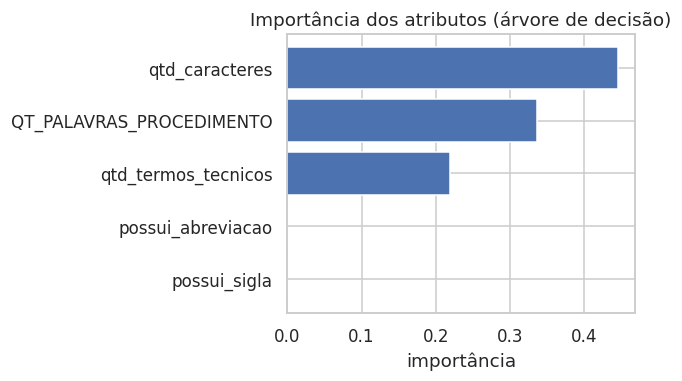

,0
qtd_caracteres,0.445409
QT_PALAVRAS_PROCEDIMENTO,0.335587
qtd_termos_tecnicos,0.219004
possui_sigla,0.000000
possui_abreviacao,0.000000


In [ ]:
# Importância dos atributos
imp = pd.Series(clf.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(6,3.6))
ax.barh(imp.index, imp.values, color="#4C72B0")
ax.set_title("Importância dos atributos (árvore de decisão)"); ax.set_xlabel("importância")
plt.tight_layout(); plt.savefig("fig_importancia.png", bbox_inches="tight"); plt.show()
imp.sort_values(ascending=False)

# 6.7 Avaliação do modelo

É fundamental avaliar um modelo de Machine Learning e entender a matriz de confusão para saber o quão bem ele está performando e onde ele está errando.

Por que devemos avaliar um modelo?
A avaliação de um modelo é crucial por diversas razões:

Entender o Desempenho: A principal razão é saber se o modelo realmente funciona. Quaisquer que sejam os objetivos do projeto (prever vendas, classificar doenças, etc.), precisamos de métricas que quantifiquem o quão bom (ou ruim) o modelo é em atingir esses objetivos.
Evitar Overfitting e Underfitting:
Overfitting (sobreajuste): O modelo aprendeu os dados de treino 'de cor', incluindo o ruído, e não consegue generalizar bem para novos dados. A avaliação em um conjunto de dados de teste (que o modelo nunca viu antes) revela isso.
Underfitting (subajuste): O modelo é muito simples e não conseguiu aprender os padrões nos dados de treino. Isso também é detectado na fase de avaliação.

Comparar Modelos: Raramente criamos apenas um modelo. A avaliação permite comparar diferentes algoritmos ou diferentes configurações do mesmo algoritmo para escolher aquele que melhor se adapta ao problema.

Tomada de Decisão: Os resultados da avaliação fornecem insights para decisões importantes. Por exemplo, em um contexto médico, um modelo com alta precisão, mas baixo recall (sensibilidade), pode ser perigoso se o custo de um falso negativo for alto.

Comunicar Resultados: Métricas de avaliação são a linguagem padrão para comunicar o desempenho de um modelo a stakeholders técnicos e não técnicos, permitindo que todos entendam as capacidades e limitações da solução.

O que é uma Matriz de Confusão?
A matriz de confusão é uma ferramenta fundamental para avaliar o desempenho de modelos de classificação. Ela sumariza os resultados de previsão de um modelo em comparação com os valores reais.

Para um problema de classificação binária (duas classes, por exemplo, 'doente' vs. 'saudável' ou 'Alta Complexidade' vs. 'Não Alta Complexidade'), a matriz de confusão tem quatro elementos:

Verdadeiros Positivos (VP): O modelo previu corretamente a classe positiva (ex: previu 'doente' e o paciente estava 'doente').

Verdadeiros Negativos (VN): O modelo previu corretamente a classe negativa (ex: previu 'saudável' e o paciente estava 'saudável').

Falsos Positivos (FP): O modelo previu incorretamente a classe positiva (ex: previu 'doente' mas o paciente estava 'saudável'). Também conhecido como Erro Tipo I.

Falsos Negativos (FN): O modelo previu incorretamente a classe negativa (ex: previu 'saudável' mas o paciente estava 'doente'). Também conhecido como Erro Tipo II.

Neste caso, a matriz de confusão que você gerou é para um problema de classificação multi-classe (Atenção Básica, Média Complexidade, Alta Complexidade). Embora mais complexa visualmente, a lógica é a mesma: cada célula (i, j) representa o número de amostras que pertenciam à classe real i e foram classificadas como classe j pelo modelo.

Como interpretá-la no seu notebook:

Observe a matriz de confusão em seu notebook:

real
previsto         Atenção Básica  Média Complexidade  Alta Complexidade

Atenção Básica                0                 109                 18
Média Complexidade            0               11561               1823
Alta Complexidade             0                4934               2901
Linhas: Representam as classes reais (os valores verdadeiros dos dados).
Colunas: Representam as classes previstas pelo modelo.
Analisando o seu resultado:

Atenção Básica: O modelo não previu nenhum procedimento como 'Atenção Básica' corretamente (0 VP na célula (Atenção Básica, Atenção Básica)). Na verdade, todos os 127 procedimentos de 'Atenção Básica' foram classificados incorretamente (109 como 'Média Complexidade' e 18 como 'Alta Complexidade'). Isso sugere que o modelo tem grande dificuldade em identificar a 'Atenção Básica'.
Média Complexidade: O modelo previu corretamente 11.561 procedimentos como 'Média Complexidade'. No entanto, ele também classificou erroneamente 1.823 procedimentos reais de 'Média Complexidade' como 'Alta Complexidade'.
Alta Complexidade: O modelo previu corretamente 2.901 procedimentos como 'Alta Complexidade'. Mas, um grande número de procedimentos reais de 'Alta Complexidade' (4.934) foi classificado erroneamente como 'Média Complexidade'.
Essa análise detalhada permite entender quais classes o modelo está confundindo e, a partir daí, pensar em estratégias para melhorar seu desempenho, como coletar mais dados para classes minoritárias, ajustar parâmetros do modelo ou rebalancear as classes.

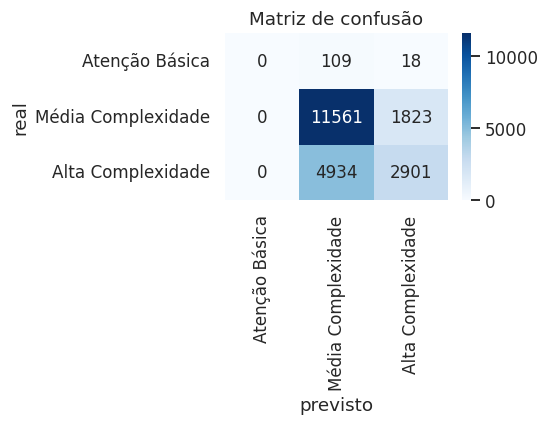

                    precision    recall  f1-score   support

    Atenção Básica       0.00      0.00      0.00       127
Média Complexidade       0.62      0.86      0.72     13482
 Alta Complexidade       0.56      0.37      0.44      7897

         micro avg       0.60      0.67      0.64     21506
         macro avg       0.39      0.41      0.39     21506
      weighted avg       0.59      0.67      0.61     21506



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(yte, pred, labels=ORDEM)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDEM, yticklabels=ORDEM, ax=ax)
ax.set_xlabel("previsto"); ax.set_ylabel("real"); ax.set_title("Matriz de confusão")
plt.tight_layout(); plt.savefig("fig_matriz_confusao.png", bbox_inches="tight"); plt.show()

print(classification_report(yte, pred, labels=ORDEM, zero_division=0))

# 6.8 Rotulação da Complexidade Técnico-Linguística

In [22]:
import pandas as pd
import numpy as np
import re
import unicodedata
from sklearn.preprocessing import MinMaxScaler

# =====================================================
# 1. Ler CID-10
# =====================================================

cid = pd.read_fwf(
    "tb_cid.txt",
    widths=[4, 100, 1, 1, 1, 4],
    names=[
        "CODIGO",
        "DESCRICAO",
        "TP_AGRAVO",
        "TP_SEXO",
        "TP_ESTADIO",
        "VL_CAMPOS_IRRADIADOS"
    ],
    dtype=str,
    encoding='latin-1' # Added encoding
)

cid["FONTE"] = "CID-10"

cid = cid[["FONTE", "CODIGO", "DESCRICAO"]]

# =====================================================
# 2. Ler procedimentos SIGTAP
# =====================================================

procedimentos = pd.read_fwf(
    "tb_procedimento.txt",
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CODIGO",
        "DESCRICAO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1' # Added encoding
)

procedimentos["FONTE"] = "SIGTAP"

procedimentos = procedimentos[["FONTE", "CODIGO", "DESCRICAO"]]

# =====================================================
# 3. Consolidar CID-10 + SIGTAP
# =====================================================

df = pd.concat(
    [cid, procedimentos],
    ignore_index=True
)

df["DESCRICAO"] = (
    df["DESCRICAO"]
    .astype(str)
    .str.strip()
)

df = df[df["DESCRICAO"] != ""]

# =====================================================
# 4. Funções auxiliares
# =====================================================

def remover_acentos(texto):
    texto = str(texto)
    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ASCII", "ignore").decode("utf-8")
    return texto


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r"[^a-zA-Z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


def tokenizar(texto):
    texto = limpar_texto(texto)
    if texto == "":
        return []
    return texto.split()


def contar_siglas(texto):
    return len(re.findall(r"\b[A-Z]{2,}\b", str(texto)))


# Aproximação simples de sílabas para português
def contar_silabas_palavra(palavra):
    palavra = remover_acentos(str(palavra).lower())
    grupos_vogais = re.findall(r"[aeiouy]+", palavra)
    return max(1, len(grupos_vogais))


def contar_silabas_texto(texto):
    palavras = tokenizar(texto)
    if len(palavras) == 0:
        return 0
    return sum(contar_silabas_palavra(p) for p in palavras)


def flesch_portugues(texto):
    palavras = tokenizar(texto)
    n_palavras = len(palavras)

    if n_palavras == 0:
        return np.nan

    n_frases = max(1, len(re.findall(r"[.!?:]", str(texto))))
    n_silabas = contar_silabas_texto(texto)

    # Fórmula de Flesch adaptada ao português
    return 248.835 - 1.015 * (n_palavras / n_frases) - 84.6 * (n_silabas / n_palavras)


# =====================================================
# 5. Dicionário de termos técnico-médicos
#    Você pode ampliar esta lista
# =====================================================

termos_medicos = [
    "abcesso", "acidente", "adenocarcinoma", "alogenico", "amputacao",
    "angiografia", "angioplastia", "anastomose", "anemia", "aneurisma",
    "antibioticoterapia", "artroplastia", "asma", "aterosclerose",
    "biopsia", "broncoscopia", "cardiomiopatia", "cateterismo",
    "cirrose", "colangiopancreatografia", "colecistectomia",
    "colonoscopia", "congenita", "craniectomia", "craniotomia",
    "dermatite", "diabetes", "diagnostico", "dialise", "displasia",
    "doenca", "eletrocardiograma", "endoscopia", "encefalopatia",
    "enxerto", "epilepsia", "estenose", "exerese", "fistula",
    "fratura", "gastrectomia", "hemodialise", "hemodinamica",
    "hemorragia", "hepatite", "hipertensao", "histerectomia",
    "imunodeficiencia", "implante", "infeccao", "insuficiencia",
    "isquemia", "laparoscopia", "lesao", "linfoma", "maligna",
    "maligno", "mastectomia", "metastase", "metastatica",
    "neoplasia", "neuropatia", "obstrucao", "osteomielite",
    "pneumonia", "politraumatismo", "radioterapia", "revascularizacao",
    "septicemia", "sindrome", "tomografia", "transplante", "tumor",
    "ulcera", "ultrassonografia", "vascular"
]

termos_medicos = set([remover_acentos(t.lower()) for t in termos_medicos])


def densidade_terminologica(texto):
    palavras = tokenizar(texto)

    if len(palavras) == 0:
        return 0

    tecnicas = sum(1 for p in palavras if p in termos_medicos)

    return tecnicas / len(palavras)


def n_termos_tecnicos(texto):
    palavras = tokenizar(texto)
    return sum(1 for p in palavras if p in termos_medicos)


# =====================================================
# 6. Calcular métricas técnico-linguísticas
# =====================================================

df["TEXTO_LIMPO"] = df["DESCRICAO"].apply(limpar_texto)

df["N_PALAVRAS"] = df["TEXTO_LIMPO"].apply(
    lambda x: len(x.split()) if x else 0
)

df["N_CARACTERES"] = df["TEXTO_LIMPO"].str.replace(" ", "", regex=False).str.len()

df["TAM_MEDIO_PALAVRA"] = np.where(
    df["N_PALAVRAS"] > 0,
    df["N_CARACTERES"] / df["N_PALAVRAS"],
    0
)

df["N_SIGLAS"] = df["DESCRICAO"].apply(contar_siglas)

df["N_SILABAS"] = df["DESCRICAO"].apply(contar_silabas_texto)

df["FLESCH_PT"] = df["DESCRICAO"].apply(flesch_portugues)

df["N_TERMOS_TECNICOS"] = df["DESCRICAO"].apply(n_termos_tecnicos)

df["DENSIDADE_TERMINOLOGICA"] = df["DESCRICAO"].apply(densidade_terminologica)

df["ESPECIFICIDADE"] = (
    df["N_PALAVRAS"] *
    df["DENSIDADE_TERMINOLOGICA"]
)

# =====================================================
# 7. Normalizar métricas
# =====================================================

metricas_para_ctl = [
    "N_PALAVRAS",
    "TAM_MEDIO_PALAVRA",
    "N_SIGLAS",
    "DENSIDADE_TERMINOLOGICA",
    "ESPECIFICIDADE"
]

scaler = MinMaxScaler()

df_norm = pd.DataFrame(
    scaler.fit_transform(df[metricas_para_ctl]),
    columns=[col + "_NORM" for col in metricas_para_ctl],
    index=df.index
)

df = pd.concat([df, df_norm], axis=1)

# Flesch: quanto menor, mais difícil.
# Portanto, invertemos a escala.
flesch_min = df["FLESCH_PT"].min()
flesch_max = df["FLESCH_PT"].max()

df["FLESCH_DIFICULDADE_NORM"] = (
    1 - ((df["FLESCH_PT"] - flesch_min) / (flesch_max - flesch_min))
)

df["FLESCH_DIFICULDADE_NORM"] = df["FLESCH_DIFICULDADE_NORM"].fillna(0)

# =====================================================
# 8. Criar escore CTL
# =====================================================

df["CTL_SCORE"] = (
    0.20 * df["N_PALAVRAS_NORM"] +
    0.20 * df["TAM_MEDIO_PALAVRA_NORM"] +
    0.15 * df["N_SIGLAS_NORM"] +
    0.25 * df["DENSIDADE_TERMINOLOGICA_NORM"] +
    0.10 * df["ESPECIFICIDADE_NORM"] +
    0.10 * df["FLESCH_DIFICULDADE_NORM"]
)

# Escala 0 a 100
df["CTL_SCORE"] = 100 * (
    (df["CTL_SCORE"] - df["CTL_SCORE"].min()) /
    (df["CTL_SCORE"].max() - df["CTL_SCORE"].min())
)

# =====================================================
# 9. Rotular Baixa / Média / Alta por percentis
# =====================================================

q33 = df["CTL_SCORE"].quantile(0.33)
q66 = df["CTL_SCORE"].quantile(0.66)

def rotular_ctl(score):
    if score <= q33:
        return "Baixa"
    elif score <= q66:
        return "Média"
    else:
        return "Alta"

df["CTL_ROTULO"] = df["CTL_SCORE"].apply(rotular_ctl)

# Versão numérica
mapa_ctl = {
    "Baixa": 0,
    "Média": 1,
    "Alta": 2
}

df["CTL_CLASSE"] = df["CTL_ROTULO"].map(mapa_ctl)

# =====================================================
# 10. Salvar dataset rotulado
# =====================================================

df.to_csv(
    "dataset_consolidado_complexidade_tecnico_linguistica.csv",
    index=False,
    encoding="utf-8-sig"
)

# =====================================================
# 11. Relatórios simples
# =====================================================

print("\nDistribuição geral da CTL:")
print(df["CTL_ROTULO"].value_counts())

print("\nDistribuição da CTL por fonte:")
print(pd.crosstab(df["FONTE"], df["CTL_ROTULO"], normalize="index") * 100)

print("\nTop 20 textos com maior complexidade técnico-linguística:")
print(
    df[
        [
            "FONTE",
            "CODIGO",
            "DESCRICAO",
            "CTL_SCORE",
            "CTL_ROTULO",
            "N_PALAVRAS",
            "TAM_MEDIO_PALAVRA",
            "DENSIDADE_TERMINOLOGICA",
            "FLESCH_PT"
        ]
    ]
    .sort_values("CTL_SCORE", ascending=False)
    .head(20)
)

print("\nArquivo gerado:")
print("dataset_consolidado_complexidade_tecnico_linguistica.csv")


Distribuição geral da CTL:
CTL_ROTULO
Alta     6537
Baixa    6350
Média    6339
Name: count, dtype: int64

Distribuição da CTL por fonte:
CTL_ROTULO       Alta      Baixa      Média
FONTE                                      
CID-10      26.218228  39.257127  34.524645
SIGTAP      56.239968  15.228732  28.531300

Top 20 textos com maior complexidade técnico-linguística:
        FONTE      CODIGO                                          DESCRICAO  \
15247  SIGTAP  0211020036                                  ELETROCARDIOGRAMA   
17102  SIGTAP  0407030026                                    COLECISTECTOMIA   
3986   CID-10         I70                                      Aterosclerose   
15210  SIGTAP  0209010045                                       LAPAROSCOPIA   
5797   CID-10         M86                                       Osteomielite   
7023   CID-10         P23                                Pneumonia congênita   
15656  SIGTAP  0301080399  MATRICIAMENTO DE EQUIPES DOS PONTOS DE 

### Explicação da Metodologia para Rotulação da Complexidade Técnico-Linguística (CTL)

O objetivo principal deste segmento de código é **gerar a variável `CTL_ROTULO`**, que classifica diagnósticos e procedimentos médicos em três níveis de complexidade técnico-linguística: 'Baixa', 'Média' e 'Alta'. Esta rotulação é feita a partir de uma série de atributos textuais extraídos das descrições e ponderados para criar um `CTL_SCORE`.

Vamos detalhar cada etapa:

---

#### **1. Leitura e Consolidação dos Dados (CID-10 e SIGTAP)**

As primeiras partes do código (_seções 1, 2 e 3_) são responsáveis por carregar os dados brutos e consolidá-los:

*   **Leitura do CID-10 (`tb_cid.txt`)**: Carrega os códigos e descrições da Classificação Estatística Internacional de Doenças e Problemas Relacionados à Saúde (CID-10).
*   **Leitura dos Procedimentos SIGTAP (`tb_procedimento.txt`)**: Carrega os códigos e descrições dos procedimentos da Tabela de Procedimentos do SUS (SIGTAP).
*   **Consolidação**: Ambos os DataFrames (`cid` e `procedimentos`) são concatenados em um único DataFrame chamado `df`. Isso cria um conjunto de dados unificado contendo tanto diagnósticos quanto procedimentos, cada um com sua `FONTE`, `CODIGO` e `DESCRICAO`.
*   **Limpeza da Coluna 'DESCRICAO'**: Garante que as descrições sejam tratadas como strings, removendo espaços em branco extras e filtrando entradas vazias.

#### **2. Funções Auxiliares de Pré-processamento de Texto**

A _seção 4_ define várias funções auxiliares cruciais para o pré-processamento do texto, permitindo a extração de métricas linguísticas:

*   **`remover_acentos(texto)`**: Remove acentos e caracteres especiais, convertendo o texto para uma forma ASCII, o que é útil para padronização e comparação de termos.
*   **`limpar_texto(texto)`**: Converte o texto para minúsculas, remove acentos, retira caracteres não alfanuméricos (exceto espaços) e padroniza múltiplos espaços, deixando o texto pronto para tokenização e análise.
*   **`tokenizar(texto)`**: Utiliza a função `limpar_texto` e divide o texto em uma lista de palavras (tokens).
*   **`contar_siglas(texto)`**: Identifica e conta sequências de duas ou mais letras maiúsculas, presumindo que sejam siglas (ex: SUS, UTI).
*   **`contar_silabas_palavra(palavra)`**: Uma aproximação simples para contar sílabas em palavras em português, baseando-se em grupos de vogais. Isso é usado na fórmula de Flesch.
*   **`contar_silabas_texto(texto)`**: Aplica `contar_silabas_palavra` a todas as palavras de um texto para obter o total de sílabas.
*   **`flesch_portugues(texto)`**: Calcula o Índice de Leiturabilidade de Flesch, adaptado para o português. Este índice avalia a facilidade de leitura de um texto: quanto maior o valor, mais fácil é a leitura. A fórmula considera o número de palavras por frase e o número de sílabas por palavra. Retorna `np.nan` se não houver palavras.

#### **3. Dicionário de Termos Técnico-Médicos**

A _seção 5_ estabelece um dicionário de termos médicos. Este é um componente chave para identificar a especificidade técnica das descrições:

*   **`termos_medicos`**: Uma lista predefinida de palavras que são consideradas termos técnico-médicos. Esta lista é convertida para um conjunto (set) e seus termos são normalizados (removendo acentos e convertendo para minúsculas) para buscas eficientes.
*   **`densidade_terminologica(texto)`**: Calcula a proporção de termos médicos presentes no texto em relação ao número total de palavras.
*   **`n_termos_tecnicos(texto)`**: Conta o número absoluto de termos médicos encontrados no texto.

#### **4. Cálculo das Métricas Técnico-Linguísticas**

Na _seção 6_, as funções auxiliares são aplicadas para derivar várias métricas para cada descrição no DataFrame `df`:

*   **`TEXTO_LIMPO`**: Versão do `DESCRICAO` após aplicar `limpar_texto`.
*   **`N_PALAVRAS`**: Número total de palavras no `TEXTO_LIMPO`.
*   **`N_CARACTERES`**: Número total de caracteres (excluindo espaços) no `TEXTO_LIMPO`.
*   **`TAM_MEDIO_PALAVRA`**: Comprimento médio das palavras (caracteres sem espaço / número de palavras).
*   **`N_SIGLAS`**: Número de siglas detectadas usando `contar_siglas`.
*   **`N_SILABAS`**: Número total de sílabas usando `contar_silabas_texto`.
*   **`FLESCH_PT`**: O índice de leiturabilidade de Flesch em português.
*   **`N_TERMOS_TECNICOS`**: O número de termos médicos do dicionário usando `n_termos_tecnicos`.
*   **`DENSIDADE_TERMINOLOGICA`**: A densidade de termos médicos usando `densidade_terminologica`.
*   **`ESPECIFICIDADE`**: Calculada como `N_PALAVRAS * DENSIDADE_TERMINOLOGICA`, buscando capturar o quão específico e extenso é o texto.

#### **5. Normalização das Métricas**

A _seção 7_ é crucial para garantir que todas as métricas contribuam igualmente para o `CTL_SCORE`, independentemente de suas escalas originais:

*   **`MinMaxScaler`**: É utilizado para escalar as métricas selecionadas (`N_PALAVRAS`, `TAM_MEDIO_PALAVRA`, `N_SIGLAS`, `DENSIDADE_TERMINOLOGICA`, `ESPECIFICIDADE`) para um intervalo de 0 a 1. Isso cria colunas com sufixo `_NORM` (ex: `N_PALAVRAS_NORM`).
*   **Normalização de Flesch**: Como um valor baixo no Flesch indica maior dificuldade, a escala é invertida (`1 - (valor_flesch_normalizado)`) para que um valor alto em `FLESCH_DIFICULDADE_NORM` corresponda a maior dificuldade (e, portanto, maior complexidade).

#### **6. Criação do `CTL_SCORE`**

A _seção 8_ combina as métricas normalizadas para formar um score único de complexidade:

*   **Média Ponderada**: O `CTL_SCORE` é calculado como uma média ponderada das métricas normalizadas. As ponderações (0.20, 0.20, 0.15, 0.25, 0.10, 0.10) são definidas heuristicamente para dar mais peso à densidade terminológica, número de palavras e tamanho médio das palavras, que são fortes indicadores de complexidade técnica.
*   **Escala para 0-100**: O score final é então escalado para um intervalo de 0 a 100 para facilitar a interpretação.

#### **7. Rotulação Baixa / Média / Alta**

A _seção 9_ categoriza o `CTL_SCORE` contínuo em rótulos discretos de complexidade:

*   **Percentis**: O `CTL_SCORE` é dividido em três categorias ('Baixa', 'Média', 'Alta') usando os percentis de 33% e 66%. Isso significa que o terço inferior dos scores é 'Baixa', o terço do meio é 'Média' e o terço superior é 'Alta'.
*   **`CTL_ROTULO`**: A coluna resultante que contém os rótulos textuais.
*   **`CTL_CLASSE`**: Uma versão numérica dos rótulos (0, 1, 2) para uso em modelos de Machine Learning.

#### **8. Salvamento e Relatórios**

As _seções 10 e 11_ finalizam o processo:

*   **Salvamento do Dataset**: O DataFrame enriquecido, contendo todas as métricas e os rótulos de complexidade, é salvo em um arquivo CSV (`dataset_consolidado_complexidade_tecnico_linguistica.csv`).
*   **Relatórios Simples**: São impressos relatórios no console para fornecer um resumo rápido da distribuição do `CTL_ROTULO` geral e por fonte (CID-10 vs. SIGTAP), além de mostrar os 20 textos com maior `CTL_SCORE`.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19226 entries, 0 to 19225
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   FONTE                         19226 non-null  object 
 1   CODIGO                        19226 non-null  object 
 2   DESCRICAO                     19226 non-null  object 
 3   TEXTO_LIMPO                   19226 non-null  object 
 4   N_PALAVRAS                    19226 non-null  int64  
 5   N_CARACTERES                  19226 non-null  int64  
 6   TAM_MEDIO_PALAVRA             19226 non-null  float64
 7   N_SIGLAS                      19226 non-null  int64  
 8   N_SILABAS                     19226 non-null  int64  
 9   FLESCH_PT                     19226 non-null  float64
 10  N_TERMOS_TECNICOS             19226 non-null  int64  
 11  DENSIDADE_TERMINOLOGICA       19226 non-null  float64
 12  ESPECIFICIDADE                19226 non-null  float64
 13  N

## 6.9 Visualização da Complexidade Técnico-Linguística

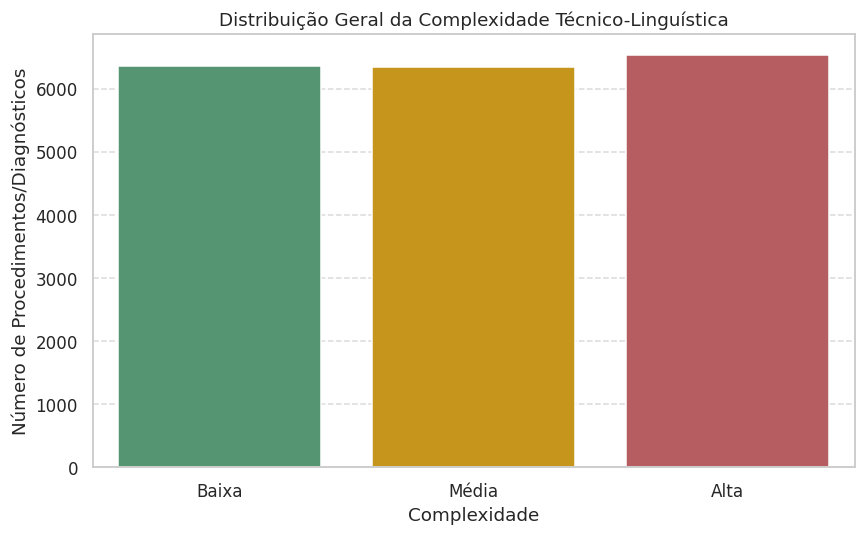

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define palette and order for CTL_ROTULO
PALETA_CTL = {"Baixa": "#4C9F70", "Média": "#E1A100", "Alta": "#C44E52"}
ORDEM_CTL = ["Baixa", "Média", "Alta"]

# 1. Overall Distribution of CTL_ROTULO
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CTL_ROTULO', order=ORDEM_CTL, palette=PALETA_CTL)
plt.title('Distribuição Geral da Complexidade Técnico-Linguística')
plt.xlabel('Complexidade')
plt.ylabel('Número de Procedimentos/Diagnósticos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A distribuição geral da complexidade técnico-linguística permite ver a proporção de itens classificados como 'Baixa', 'Média' e 'Alta' complexidade em todo o dataset.

<Figure size 1100x660 with 0 Axes>

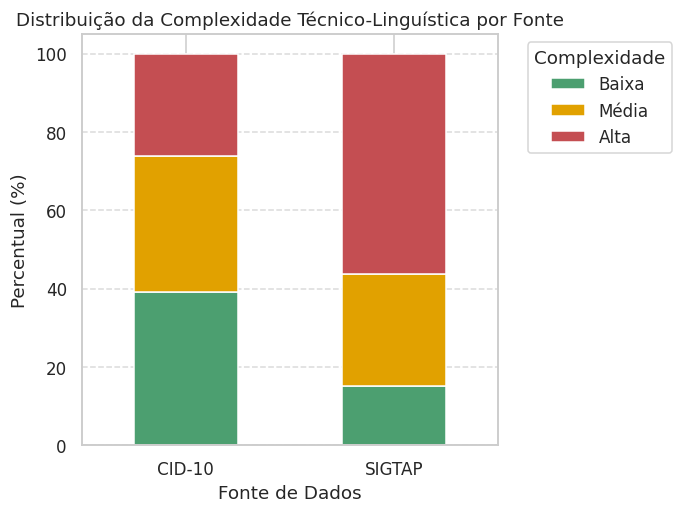

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define palette and order for CTL_ROTULO
PALETA_CTL = {"Baixa": "#4C9F70", "Média": "#E1A100", "Alta": "#C44E52"}
ORDEM_CTL = ["Baixa", "Média", "Alta"]

# 2. Distribution of CTL_ROTULO by Source (FONTE)
ctl_by_source = df.groupby('FONTE')['CTL_ROTULO'].value_counts(normalize=True).mul(100).unstack().fillna(0)
ctl_by_source = ctl_by_source[ORDEM_CTL] # Ensure consistent order

plt.figure(figsize=(10, 6))
ctl_by_source.plot(kind='bar', stacked=True, color=[PALETA_CTL[c] for c in ORDEM_CTL])
plt.title('Distribuição da Complexidade Técnico-Linguística por Fonte')
plt.xlabel('Fonte de Dados')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend(title='Complexidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparação entre Complexidade Técnico-Linguística (CTL) e Complexidade Assistencial (SIGTAP)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define custom color palettes and orders for consistency
PALETA_CTL = {"Baixa": "#4C9F70", "Média": "#E1A100", "Alta": "#C44E52"}
ORDEM_CTL = ["Baixa", "Média", "Alta"]

PALETA_ASSIST = {"Atenção Básica": "#4C9F70", "Média Complexidade": "#E1A100", "Alta Complexidade": "#C44E52"}
ORDEM_ASSIST = ["Atenção Básica", "Média Complexidade", "Alta Complexidade"]

# 1. Load the dataset with CTL_ROTULO
df_ctl = pd.read_csv('dataset_consolidado_complexidade_tecnico_linguistica.csv')

# 2. Load the raw procedimientos data to get TP_COMPLEXIDADE (assistential complexity)
# Ensure this is loaded at the beginning of the cell to prevent NameError
procedimientos_raw = pd.read_fwf(
    'tb_procedimento.txt',
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        'CODIGO',
        'NO_PROCEDIMENTO',
        'TP_COMPLEXIDADE',
        'TP_SEXO',
        'QT_MAXIMA_EXECUCAO',
        'QT_DIAS_PERMANENCIA',
        'QT_PONTOS',
        'VL_IDADE_MINIMA',
        'VL_IDADE_MAXIMA',
        'VL_SH',
        'VL_SA',
        'VL_SP',
        'CO_FINANCIAMENTO',
        'CO_RUBRICA',
        'QT_TEMPO_PERMANENCIA',
        'DT_COMPETENCIA'
    ],
    dtype=str,
    encoding='latin-1'
)

# Added for debugging and to ensure variable existence
print("procedimientos_raw loaded successfully. Head:")
display(procedimientos_raw.head())

# Map TP_COMPLEXIDADE to descriptive labels for assistential complexity
mapa_complexidade_assist = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}
procedimientos_raw['COMPLEXIDADE_ASSISTENCIAL'] = procedimientos_raw['TP_COMPLEXIDADE'].map(mapa_complexidade_assist)

# 3. Filter df_ctl for SIGTAP entries and merge assistential complexity
df_sigtap_merged = df_ctl[df_ctl['FONTE'] == 'SIGTAP'].copy()

# Rename 'CODIGO' in procedimientos_raw to match 'CODIGO' in df_sigtap_merged for merging
procedimientos_raw = procedimientos_raw.rename(columns={'CODIGO': 'CODIGO_PROCEDIMENTO'})

# Perform the merge. Ensure 'CODIGO' in df_sigtap_merged and 'CODIGO_PROCEDIMENTO' in procedimientos_raw are clean
df_sigtap_merged['CODIGO'] = df_sigtap_merged['CODIGO'].str.strip()
procedimientos_raw['CODIGO_PROCEDIMENTO'] = procedimientos_raw['CODIGO_PROCEDIMENTO'].str.strip()

df_sigtap_merged = df_sigtap_merged.merge(
    procedimientos_raw[['CODIGO_PROCEDIMENTO', 'COMPLEXIDADE_ASSISTENCIAL']],
    left_on='CODIGO',
    right_on='CODIGO_PROCEDIMENTO',
    how='left'
)

# Drop the redundant CODIGO_PROCEDIMENTO column from the merge
df_sigtap_merged.drop(columns=['CODIGO_PROCEDIMENTO'], inplace=True)

# Fill any potential NaN values in COMPLEXIDADE_ASSISTENCIAL that might arise from merge mismatches
df_sigtap_merged['COMPLEXIDADE_ASSISTENCIAL'] = df_sigtap_merged['COMPLEXIDADE_ASSISTENCIAL'].fillna('Não informado')

print("DataFrame with merged complexities for SIGTAP data:")
display(df_sigtap_merged[['CODIGO', 'CTL_ROTULO', 'COMPLEXIDADE_ASSISTENCIAL']].head())

procedimientos_raw loaded successfully. Head:


,CODIGO,NO_PROCEDIMENTO,TP_COMPLEXIDADE,TP_SEXO,QT_MAXIMA_EXECUCAO,QT_DIAS_PERMANENCIA,QT_PONTOS,VL_IDADE_MINIMA,VL_IDADE_MAXIMA,VL_SH,VL_SA,VL_SP,CO_FINANCIAMENTO,CO_RUBRICA,QT_TEMPO_PERMANENCIA,DT_COMPETENCIA
0,0101010010,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,1,N,9999,9999,0000,9999,9999,000000000000,000000000000,000000000000,01,NaN,9999,202605
1,0101010028,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...,2,I,9999,9999,0000,0084,1571,000000000000,000000000270,000000000000,06,NaN,9999,202605
2,0101010036,PRÁTICA CORPORAL / ATIVIDADE FÍSICA EM GRUPO,1,I,9999,9999,0000,0072,1571,000000000000,000000000000,000000000000,01,NaN,9999,202605
3,0101010095,PREVENÇÃO DA COVID-19 NAS ESCOLAS,1,I,9999,9999,0000,0000,1571,000000000000,000000000000,000000000000,01,NaN,9999,202605
4,0101010109,ATIVIDADES EDUCATIVAS DA POPULAÇÃO SOBRE A TEM...,1,I,9999,9999,0000,0000,1571,000000000000,000000000000,000000000000,07,NaN,9999,202605


DataFrame with merged complexities for SIGTAP data:


,CODIGO,CTL_ROTULO,COMPLEXIDADE_ASSISTENCIAL
0,0101010010,Alta,Atenção Básica
1,0101010028,Alta,Média Complexidade
2,0101010036,Média,Atenção Básica
3,0101010095,Baixa,Atenção Básica
4,0101010109,Alta,Atenção Básica



Cross-tabulation (Percentage) of CTL_ROTULO by COMPLEXIDADE_ASSISTENCIAL:


CTL_ROTULO,Baixa,Média,Alta
COMPLEXIDADE_ASSISTENCIAL,,,
Atenção Básica,27.426160,32.489451,40.084388
Média Complexidade,15.422277,29.171767,55.405957
Alta Complexidade,10.677242,26.052471,63.270287


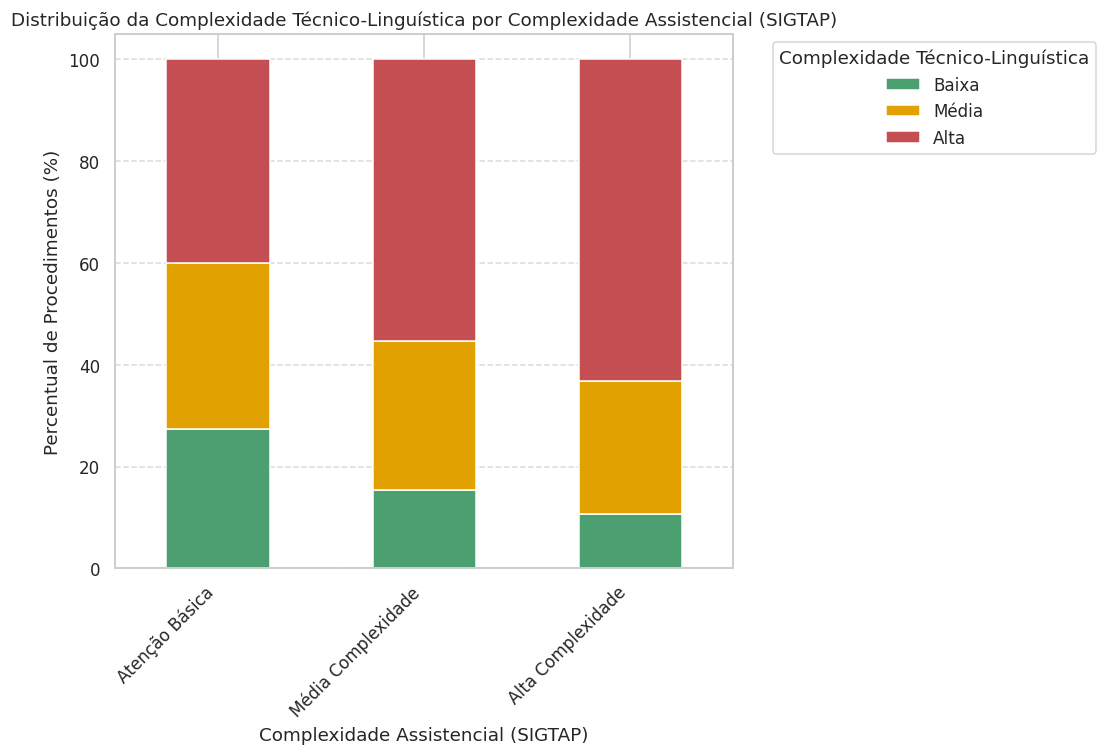

In [36]:
# Re-initialize df_sigtap_merged to ensure COMPLEXIDADE_ASSISTENCIAL is present
# This code is duplicated from cell 91c10823 to ensure robustness

# Assuming df_ctl and procedimientos_raw are already loaded and processed from the previous cell
# If not, ensure they are here or in an earlier cell:
# df_ctl = pd.read_csv('dataset_consolidado_complexidade_tecnico_linguistica.csv')
# procedimientos_raw is expected to have 'COMPLEXIDADE_ASSISTENCIAL' and 'CODIGO_PROCEDIMENTO' at this point.

# Map TP_COMPLEXIDADE to descriptive labels for assistential complexity (if not already done for procedimientos_raw)
mapa_complexidade_assist = {
    "1": "Atenção Básica",
    "2": "Média Complexidade",
    "3": "Alta Complexidade"
}
# Ensure procedimientos_raw has the COMPLEXIDADE_ASSISTENCIAL column
# This part assumes 'procedimientos_raw' (from the previous cell's final state) is already named 'CODIGO_PROCEDIMENTO'
# and has 'COMPLEXIDADE_ASSISTENCIAL' generated.
# If `procedimientos_raw` still has 'CODIGO', rename it first:
if 'CODIGO' in procedimientos_raw.columns and 'CODIGO_PROCEDIMENTO' not in procedimientos_raw.columns:
    procedimientos_raw = procedimientos_raw.rename(columns={'CODIGO': 'CODIGO_PROCEDIMENTO'})

# And ensure COMPLEXIDADE_ASSISTENCIAL is mapped
if 'TP_COMPLEXIDADE' in procedimientos_raw.columns and 'COMPLEXIDADE_ASSISTENCIAL' not in procedimientos_raw.columns:
    procedimientos_raw['COMPLEXIDADE_ASSISTENCIAL'] = procedimientos_raw['TP_COMPLEXIDADE'].map(mapa_complexidade_assist)

# Filter df_ctl for SIGTAP entries
df_sigtap_merged = df_ctl[df_ctl['FONTE'] == 'SIGTAP'].copy()

# Clean 'CODIGO' columns for merging
df_sigtap_merged['CODIGO'] = df_sigtap_merged['CODIGO'].str.strip()
procedimientos_raw['CODIGO_PROCEDIMENTO'] = procedimientos_raw['CODIGO_PROCEDIMENTO'].str.strip()

# Perform the merge to add assistential complexity to df_sigtap_merged
df_sigtap_merged = df_sigtap_merged.merge(
    procedimientos_raw[['CODIGO_PROCEDIMENTO', 'COMPLEXIDADE_ASSISTENCIAL']],
    left_on='CODIGO',
    right_on='CODIGO_PROCEDIMENTO',
    how='left'
)

# Drop the redundant CODIGO_PROCEDIMENTO column from the merge
df_sigtap_merged.drop(columns=['CODIGO_PROCEDIMENTO'], inplace=True)

# Fill any potential NaN values in COMPLEXIDADE_ASSISTENCIAL
df_sigtap_merged['COMPLEXIDADE_ASSISTENCIAL'] = df_sigtap_merged['COMPLEXIDADE_ASSISTENCIAL'].fillna('Não informado')

# 4. Create a cross-tabulation of CTL_ROTULO and COMPLEXIDADE_ASSISTENCIAL
comparison_table = pd.crosstab(
    df_sigtap_merged['COMPLEXIDADE_ASSISTENCIAL'],
    df_sigtap_merged['CTL_ROTULO'],
    normalize='index' # Normalize by row to show distribution of CTL_ROTULO within each Assistential Complexity
).mul(100)

# Ensure consistent order for both axes
comparison_table = comparison_table.reindex(ORDEM_ASSIST)
comparison_table = comparison_table[ORDEM_CTL] # Ensure CTL columns are in the correct order

print("\nCross-tabulation (Percentage) of CTL_ROTULO by COMPLEXIDADE_ASSISTENCIAL:")
display(comparison_table)

# 5. Visualize the comparison using a stacked bar chart
fig, ax = plt.subplots(figsize=(10, 7))
comparison_table.plot(kind='bar', stacked=True, ax=ax, color=[PALETA_CTL[c] for c in ORDEM_CTL])

plt.title('Distribuição da Complexidade Técnico-Linguística por Complexidade Assistencial (SIGTAP)')
plt.xlabel('Complexidade Assistencial (SIGTAP)')
plt.ylabel('Percentual de Procedimentos (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complexidade Técnico-Linguística', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("comparacao_ctl_assistencial_sigtap.png", dpi=300)
plt.show()

Este gráfico de barras empilhadas mostra a distribuição percentual da Complexidade Técnico-Linguística (`CTL_ROTULO`) dentro de cada categoria de Complexidade Assistencial (`COMPLEXIDADE_ASSISTENCIAL`) para os procedimentos da fonte SIGTAP. Ele permite observar se procedimentos classificados como 'Alta Complexidade' assistencialmente também tendem a ser 'Alta' em termos técnico-linguísticos, ou se há variações significativas.

Este gráfico de barras empilhadas mostra a proporção de cada nível de complexidade ('Baixa', 'Média', 'Alta') dentro de cada fonte de dados (CID-10 e SIGTAP). Isso é útil para entender se a complexidade técnico-linguística varia significativamente entre os diagnósticos e procedimentos de diferentes origens.

In [37]:
df.describe()

,N_PALAVRAS,N_CARACTERES,TAM_MEDIO_PALAVRA,N_SIGLAS,N_SILABAS,FLESCH_PT,N_TERMOS_TECNICOS,DENSIDADE_TERMINOLOGICA,ESPECIFICIDADE,N_PALAVRAS_NORM,TAM_MEDIO_PALAVRA_NORM,N_SIGLAS_NORM,DENSIDADE_TERMINOLOGICA_NORM,ESPECIFICIDADE_NORM,FLESCH_DIFICULDADE_NORM,CTL_SCORE,CTL_CLASSE
count,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000,19226.000000
mean,7.295745,44.098044,6.647193,1.381046,18.204463,10.235743,0.252991,0.040854,0.252991,0.161429,0.158574,0.051150,0.040854,0.084330,0.179848,21.320675,1.009726
std,4.080404,20.037590,1.881591,2.717993,8.279843,64.888762,0.525820,0.095831,0.525820,0.104626,0.081808,0.100666,0.095831,0.175273,0.076793,10.225257,0.818676
min,1.000000,4.000000,3.000000,0.000000,2.000000,-682.780000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,28.000000,5.400000,0.000000,12.000000,-12.070000,0.000000,0.000000,0.000000,0.076923,0.104348,0.000000,0.000000,0.000000,0.130777,14.568913,0.000000
50%,7.000000,42.000000,6.333333,0.000000,17.000000,20.886154,0.000000,0.000000,0.000000,0.153846,0.144928,0.000000,0.000000,0.000000,0.167244,18.488753,1.000000
75%,10.000000,59.000000,7.428571,1.000000,24.000000,51.700000,0.000000,0.000000,0.000000,0.230769,0.192547,0.037037,0.000000,0.000000,0.206246,26.495751,2.000000
max,40.000000,208.000000,26.000000,27.000000,90.000000,162.205000,3.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000,2.000000


In [39]:
df.head(20)

,FONTE,CODIGO,DESCRICAO,TEXTO_LIMPO,N_PALAVRAS,N_CARACTERES,TAM_MEDIO_PALAVRA,N_SIGLAS,N_SILABAS,FLESCH_PT,...,ESPECIFICIDADE,N_PALAVRAS_NORM,TAM_MEDIO_PALAVRA_NORM,N_SIGLAS_NORM,DENSIDADE_TERMINOLOGICA_NORM,ESPECIFICIDADE_NORM,FLESCH_DIFICULDADE_NORM,CTL_SCORE,CTL_ROTULO,CTL_CLASSE
0,CID-10,A00,Cólera,colera,1,6,6.000000,0,3,-5.980,...,0.0,0.000000,0.130435,0.0,0.000000,0.000000,0.199039,7.787377,Baixa,0
1,CID-10,A000,"Cólera devida a Vibrio Cholerae 01, biótipo Ch...",colera devida a vibrio cholerae 01 biotipo cho...,8,44,5.500000,0,19,39.790,...,0.0,0.179487,0.108696,0.0,0.000000,0.000000,0.144872,13.462953,Baixa,0
2,CID-10,A001,"Cólera devida a Vibrio Cholerae 01, biótipo El...",colera devida a vibrio cholerae 01 biotipo el tor,9,41,4.555556,0,18,70.500,...,0.0,0.205128,0.067633,0.0,0.000000,0.000000,0.108529,12.003771,Baixa,0
3,CID-10,A009,Cólera não especificada,colera nao especificada,3,21,7.000000,0,10,-36.210,...,0.0,0.051282,0.173913,0.0,0.000000,0.000000,0.234815,12.680384,Baixa,0
4,CID-10,A01,Febres tifóide e paratifóide,febres tifoide e paratifoide,4,25,6.250000,0,11,12.125,...,0.0,0.076923,0.141304,0.0,0.000000,0.000000,0.177613,11.135413,Baixa,0
5,CID-10,A010,Febre tifóide,febre tifoide,2,12,6.000000,0,5,35.305,...,0.0,0.025641,0.130435,0.0,0.000000,0.000000,0.150180,7.840005,Baixa,0
6,CID-10,A011,Febre paratifóide A,febre paratifoide a,3,17,5.666667,0,8,20.190,...,0.0,0.051282,0.115942,0.0,0.000000,0.000000,0.168068,8.712734,Baixa,0
7,CID-10,A012,Febre paratifóide B,febre paratifoide b,3,17,5.666667,0,8,20.190,...,0.0,0.051282,0.115942,0.0,0.000000,0.000000,0.168068,8.712734,Baixa,0
8,CID-10,A013,Febre paratifóide C,febre paratifoide c,3,17,5.666667,0,8,20.190,...,0.0,0.051282,0.115942,0.0,0.000000,0.000000,0.168068,8.712734,Baixa,0
9,CID-10,A014,Febre paratifóide não especificada,febre paratifoide nao especificada,4,31,7.750000,0,14,-51.325,...,0.0,0.076923,0.206522,0.0,0.000000,0.000000,0.252703,15.599019,Baixa,0


# 6.9 Validar a Hipótese Científica (Parcialmente)

"Procedimentos classificados como Alta Complexidade no SUS estão associados principalmente a maiores valores financeiros, maior tempo de permanência hospitalar, grupos cirúrgicos/transplantes e diagnósticos pertencentes aos capítulos de neoplasias, doenças circulatórias e doenças do sistema nervoso."


Acurácia:
0.8820224719101124

Matriz de confusão:
[[802  34]
 [113 297]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       836
           1       0.90      0.72      0.80       410

    accuracy                           0.88      1246
   macro avg       0.89      0.84      0.86      1246
weighted avg       0.88      0.88      0.88      1246


Importância das variáveis:
                                           VARIAVEL  IMPORTANCIA
138                         num__QT_MAXIMA_EXECUCAO     0.360917
34                              cat__CO_SUBGRUPO_04     0.241370
30               cat__GRUPO_SIGTAP_Órteses/próteses     0.232926
133                                      num__VL_SP     0.117811
132                                      num__VL_SA     0.026821
43                              cat__CO_SUBGRUPO_13     0.014076
131                                      num__VL_SH     0.006080
3               cat__C

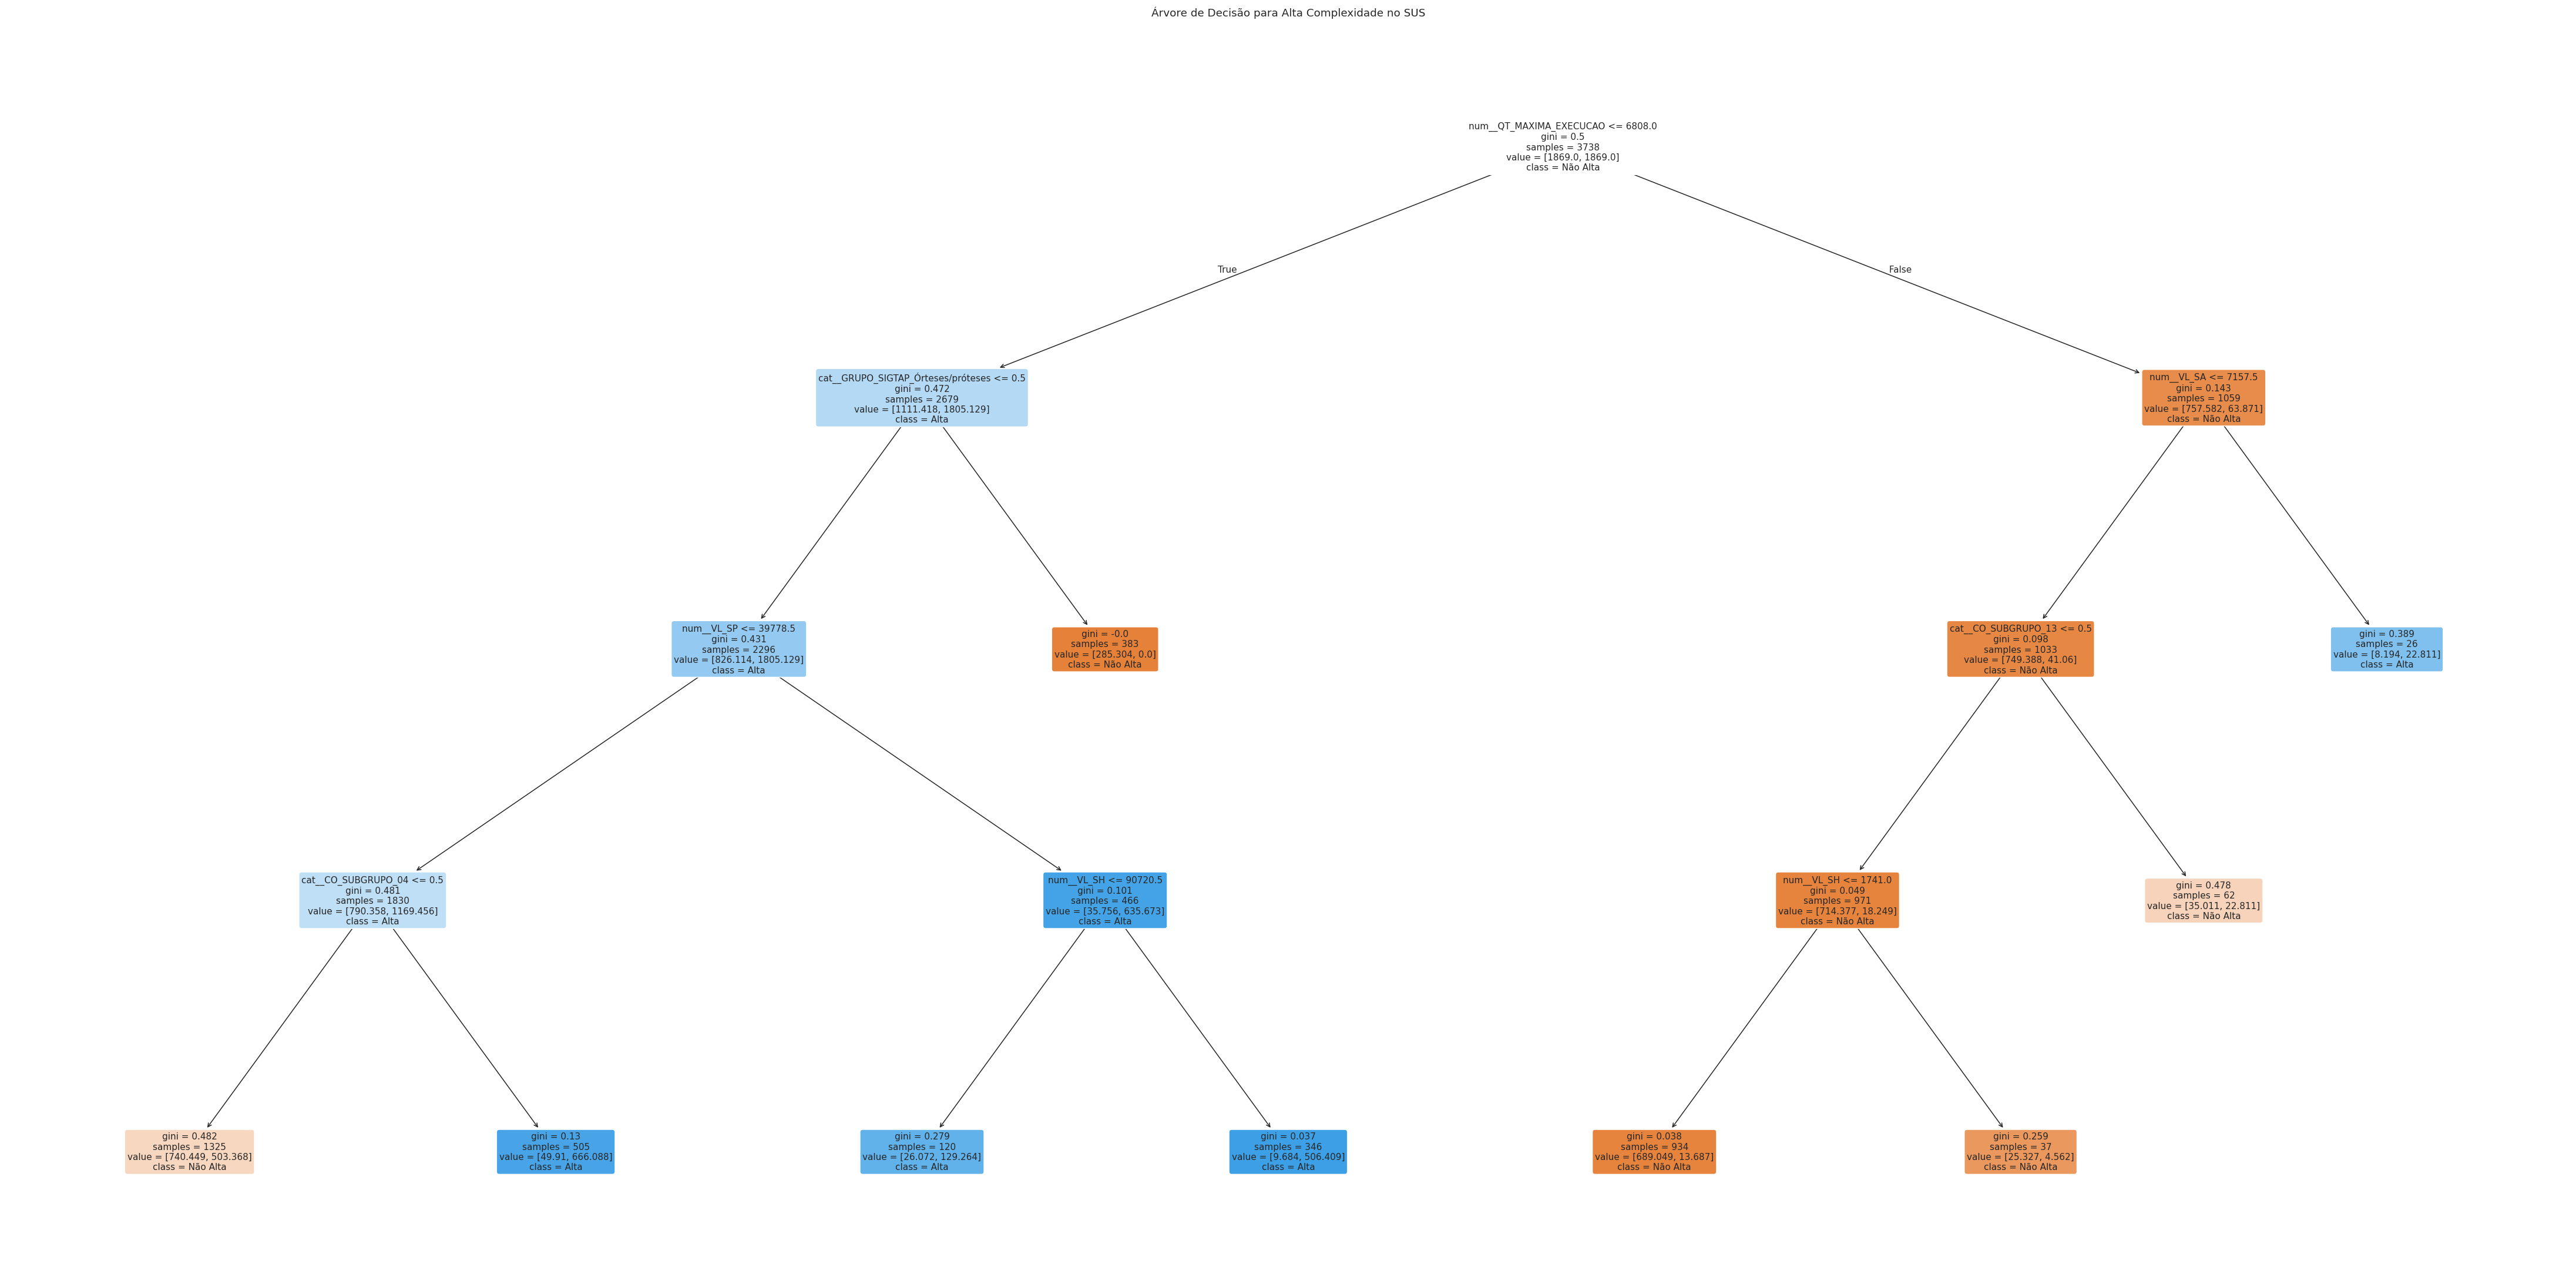

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# =====================================================
# 1. Ler arquivos SIGTAP (diretamente do diretório /files)
# =====================================================

rl_proc_cid_path = '/content/rl_procedimento_cid.txt'
tb_procedimento_path = '/content/tb_procedimento.txt'

# Check if files exist before attempting to read
if not os.path.exists(rl_proc_cid_path):
    print(f"Error: File not found at {rl_proc_cid_path}. Please ensure it's uploaded.")
    raise FileNotFoundError(f"File not found: {rl_proc_cid_path}")
if not os.path.exists(tb_procedimento_path):
    print(f"Error: File not found at {tb_procedimento_path}. Please ensure it's uploaded.")
    raise FileNotFoundError(f"File not found: {tb_procedimento_path}")

proc_cid = pd.read_fwf(
    rl_proc_cid_path,
    widths=[10, 4, 1, 6],
    names=["CO_PROCEDIMENTO", "CO_CID", "ST_PRINCIPAL", "DT_COMPETENCIA"],
    dtype=str,
    encoding='latin-1'
)

procedimentos = pd.read_fwf(
    tb_procedimento_path,
    widths=[10,250,1,1,4,4,4,4,4,12,12,12,2,6,4,6],
    names=[
        "CO_PROCEDIMENTO",
        "NO_PROCEDIMENTO",
        "TP_COMPLEXIDADE",
        "TP_SEXO",
        "QT_MAXIMA_EXECUCAO",
        "QT_DIAS_PERMANENCIA",
        "QT_PONTOS",
        "VL_IDADE_MINIMA",
        "VL_IDADE_MAXIMA",
        "VL_SH",
        "VL_SA",
        "VL_SP",
        "CO_FINANCIAMENTO",
        "CO_RUBRICA",
        "QT_TEMPO_PERMANENCIA",
        "DT_COMPETENCIA"
    ],
    dtype=str,
    encoding='latin-1'
)


# =====================================================
# 2. Função para capítulo CID-10
# =====================================================

def capitulo_cid10(cid):
    if pd.isna(cid):
        return "Sem CID"

    cid = str(cid).strip()

    if cid == "":
        return "Sem CID"

    letra = cid[0]

    mapa = {
        "A": "I - Infecciosas",
        "B": "I - Infecciosas",
        "C": "II - Neoplasias",
        "D": "III - Sangue/Imunidade",
        "E": "IV - Endócrinas",
        "F": "V - Mentais",
        "G": "VI - Sistema Nervoso",
        "H": "VII/VIII - Olhos/Ouvidos",
        "I": "IX - Circulatórias",
        "J": "X - Respiratórias",
        "K": "XI - Digestivas",
        "L": "XII - Pele",
        "M": "XIII - Musculoesqueléticas",
        "N": "XIV - Geniturinárias",
        "O": "XV - Gravidez/Parto",
        "P": "XVI - Perinatais",
        "Q": "XVII - Congênitas",
        "R": "XVIII - Sintomas/Sinais",
        "S": "XIX - Lesões/Traumas",
        "T": "XIX - Lesões/Traumas",
        "V": "XX - Causas Externas",
        "W": "XX - Causas Externas",
        "X": "XX - Causas Externas",
        "Y": "XX - Causas Externas",
        "Z": "XXI - Fatores Saúde"
    }

    return mapa.get(letra, "Outros")


proc_cid["CAPITULO_CID10"] = proc_cid["CO_CID"].apply(capitulo_cid10)


# =====================================================
# 3. Criar variáveis SIGTAP
# =====================================================

procedimentos["CO_GRUPO"] = procedimentos["CO_PROCEDIMENTO"].str[0:2]
procedimentos["CO_SUBGRUPO"] = procedimentos["CO_PROCEDIMENTO"].str[2:4]
procedimentos["CO_FORMA_ORGANIZACAO"] = procedimentos["CO_PROCEDIMENTO"].str[4:6]

mapa_grupo = {
    "01": "Ações promoção/prevenção",
    "02": "Procedimentos diagnósticos",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes",
    "06": "Medicamentos",
    "07": "Órteses/próteses",
    "08": "Ações complementares"
}

procedimentos["GRUPO_SIGTAP"] = procedimentos["CO_GRUPO"].map(mapa_grupo).fillna("Outro")


# =====================================================
# 4. Converter variáveis numéricas
# =====================================================

numeric_cols = [
    "VL_SH",
    "VL_SA",
    "VL_SP",
    "QT_DIAS_PERMANENCIA",
    "QT_TEMPO_PERMANENCIA",
    "VL_IDADE_MINIMA",
    "VL_IDADE_MAXIMA",
    "QT_MAXIMA_EXECUCAO"
]

for col in numeric_cols:
    procedimentos[col] = (
        procedimentos[col]
        .str.strip()
        .replace("", np.nan)
        .astype(float)
    )


# =====================================================
# 5. Criar número de CIDs associados por procedimento
# =====================================================

qtd_cids = (
    proc_cid
    .groupby("CO_PROCEDIMENTO")["CO_CID"]
    .nunique()
    .reset_index(name="N_CIDS_ASSOCIADOS")
)


# =====================================================
# 6. Capítulo CID dominante por procedimento
# =====================================================

capitulo_dominante = (
    proc_cid
    .groupby(["CO_PROCEDIMENTO", "CAPITULO_CID10"])
    .size()
    .reset_index(name="N")
    .sort_values(["CO_PROCEDIMENTO", "N"], ascending=[True, False])
    .drop_duplicates("CO_PROCEDIMENTO")
    [["CO_PROCEDIMENTO", "CAPITULO_CID10"]]
)


# =====================================================
# 7. Montar base de modelagem
# =====================================================

base = (
    procedimentos
    .merge(qtd_cids, on="CO_PROCEDIMENTO", how="left")
    .merge(capitulo_dominante, on="CO_PROCEDIMENTO", how="left")
)

base["N_CIDS_ASSOCIADOS"] = base["N_CIDS_ASSOCIADOS"].fillna(0)
base["CAPITULO_CID10"] = base["CAPITULO_CID10"].fillna("Sem CID")

base["ALTA_COMPLEXIDADE"] = np.where(
    base["TP_COMPLEXIDADE"].str.strip() == "3",
    1,
    0
)


# =====================================================
# 8. Selecionar variáveis explicativas
# =====================================================

features_categoricas = [
    "CAPITULO_CID10",
    "GRUPO_SIGTAP",
    "CO_SUBGRUPO",
    "CO_FORMA_ORGANIZACAO",
    "TP_SEXO"
]

features_numericas = [
    "N_CIDS_ASSOCIADOS",
    "VL_SH",
    "VL_SA",
    "VL_SP",
    "QT_DIAS_PERMANENCIA",
    "QT_TEMPO_PERMANENCIA",
    "VL_IDADE_MINIMA",
    "VL_IDADE_MAXIMA",
    "QT_MAXIMA_EXECUCAO"
]

features = features_categoricas + features_numericas

df_modelo = base[
    features + ["ALTA_COMPLEXIDADE", "CO_PROCEDIMENTO", "NO_PROCEDIMENTO"]
].copy()

df_modelo[features_numericas] = df_modelo[features_numericas].fillna(0)
df_modelo[features_categoricas] = df_modelo[features_categoricas].fillna("Não informado")


# =====================================================
# 9. Separar treino e teste
# =====================================================

X = df_modelo[features]
y = df_modelo["ALTA_COMPLEXIDADE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# =====================================================
# 10. Pré-processamento + árvore de decisão
# =====================================================

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
        ("num", "passthrough", features_numericas)
    ]
)

modelo = Pipeline(
    steps=[
        ("preprocessador", preprocessador),
        ("arvore", DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=20,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

modelo.fit(X_train, y_train)


# =====================================================
# 11. Avaliação
# =====================================================

y_pred = modelo.predict(X_test)

print("\nAcurácia:")
print(accuracy_score(y_test, y_pred))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))


# =====================================================
# 12. Importância das variáveis
# =====================================================

feature_names = (
    modelo.named_steps["preprocessador"]
    .get_feature_names_out()
)

importancias = modelo.named_steps["arvore"].feature_importances_

df_importancias = (
    pd.DataFrame({
        "VARIAVEL": feature_names,
        "IMPORTANCIA": importancias
    })
    .sort_values("IMPORTANCIA", ascending=False)
)

print("\nImportância das variáveis:")
print(df_importancias.head(30))

df_importancias.to_csv(
    "importancia_variaveis_alta_complexidade.csv",
    index=False,
    encoding="utf-8-sig"
)


# =====================================================
# 13. Regras da árvore em texto
# =====================================================

regras = export_text(
    modelo.named_steps["arvore"],
    feature_names=list(feature_names)
)

print("\nRegras da árvore:")
print(regras)

with open("regras_arvore_alta_complexidade.txt", "w", encoding="utf-8") as f:
    f.write(regras)


# =====================================================
# 14. Visualizar árvore
# =====================================================

plt.figure(figsize=(40, 20)) # Increased figure size

plot_tree(
    modelo.named_steps["arvore"],
    feature_names=feature_names,
    class_names=["Não Alta", "Alta"],
    filled=True,
    rounded=True,
    fontsize=10 # Increased font size
)

plt.title("Árvore de Decisão para Alta Complexidade no SUS")
plt.tight_layout()
plt.savefig("arvore_decisao_alta_complexidade.png", dpi=300)
plt.show()


# =====================================================
# 15. Salvar base usada no modelo
# =====================================================

df_modelo.to_csv(
    "base_modelo_alta_complexidade.csv",
    index=False,
    encoding="utf-8-sig"
)


# Interpretação da Árvore de Decisão

The tree starts by looking at num__QT_MAXIMA_EXECUCAO (Maximum Execution Quantity) and splits at a value of 6808.00.

If num__QT_MAXIMA_EXECUCAO <= 6808.00 (Left Branch):

This is the most common path, covering the majority of samples (57300).
The next split checks cat__GRUPO_SIGTAP_Órteses/próteses (Sigtap Group: Orthoses/Prostheses).
If cat__GRUPO_SIGTAP_Órteses/próteses <= 0.50 (meaning it's not an orthoses/prostheses procedure):
The tree then looks at num__VL_SP (Service Value) at 39778.50.
If num__VL_SP <= 39778.50: It then considers cat__CO_SUBGRUPO_04 (Subgroup 04). If this is 0.50 or less, it tends to classify as Não Alta (Not High Complexity). If it's more than 0.50, it classifies as Alta (High Complexity).
If num__VL_SP > 39778.50: It then considers num__VL_SH (Hospital Service Value) at 90720.50. In both sub-branches of this split, the class is Alta (High Complexity), suggesting that a high num__VL_SP is a strong indicator.
If cat__GRUPO_SIGTAP_Órteses/próteses > 0.50 (meaning it is an orthoses/prostheses procedure):
This path directly leads to a Não Alta (Not High Complexity) classification, indicating that these procedures, despite potentially having a high QT_MAXIMA_EXECUCAO, are generally not considered 'Alta Complexidade'.
If num__QT_MAXIMA_EXECUCAO > 6808.00 (Right Branch):

This branch covers a smaller number of samples (750)
The split here is based on num__VL_SA (Anesthesia Service Value) at 7157.50.
If num__VL_SA <= 7157.50: It checks cat__CO_SUBGRUPO_13 and num__VL_SH. This path mostly leads to Não Alta (Not High Complexity) classifications.
If num__VL_SA > 7157.50: This path directly leads to an Alta (High Complexity) classification, suggesting that procedures with a very high maximum execution quantity and high anesthesia service value are strongly 'Alta Complexidade'.
In summary:

QT_MAXIMA_EXECUCAO (Maximum Execution Quantity) is the primary differentiator.
For procedures with lower maximum execution quantities, VL_SP (Service Value) and the GRUPO_SIGTAP (especially Orthoses/Prostheses) are critical. High VL_SP values strongly push towards 'Alta Complexidade', while Orthoses/Prostheses procedures tend to be 'Não Alta'.
For procedures with very high maximum execution quantities, a high VL_SA (Anesthesia Service Value) is a strong indicator of 'Alta Complexidade'.

# Hipótese bem Sustentada

Para uma dissertação ou artigo, deveria ser feita a sequência a seguir:

1. EDA

2. Testes estatísticos

3. Árvore de decisão

4. Random Forest

5. Regressão Logística

6. Comparação dos resultados

A hipótese estaria bem sustentada se os três modelos apontassem consistentemente:

VL_SH
Grupo SIGTAP
Capítulo CID
Tempo de permanência

como principais determinantes da Alta Complexidade.

Na verdade, para os dados do SIGTAP, eu suspeito que VL_SH, Grupo SIGTAP e Tempo de Permanência responderão por mais de 70% do poder explicativo do modelo. Isso seria uma conclusão bastante interessante sobre a estrutura da assistência de alta complexidade no SUS.

# 7. Discussão, limitações e trabalhos futuros

**Discussão.** O dataset permitiu caracterizar a complexidade técnico‑linguística e, de forma
consistente, **procedimentos (SIGTAP) tendem a ser mais complexos que diagnósticos (CID‑10)** — suas
descrições são mais longas e densas em termos técnicos. A árvore de decisão indicou que extensão do
texto e densidade de termos técnicos são os atributos mais determinantes.

**Limitações.**
- A variável de complexidade é **heurística** (regras + tercis), não uma medida validada de
  compreensão real por pacientes; os resultados são **exploratórios**.
- Como o alvo deriva dos próprios atributos, a árvore tende a *recuperar* a regra — seu valor aqui é
  **interpretativo**.
- A detecção de termos técnicos por morfologia/léxico pode gerar falsos positivos/negativos.

**Trabalhos futuros.**
- Validar a complexidade com profissionais de saúde e/ou métricas de legibilidade.
- Enriquecer o léxico técnico com **DeCS/MeSH** completo e *embeddings*.
- Conectar ao **Traduz Saúde**: priorizar a simplificação dos itens classificados como de alta
  complexidade.
- Migrar para a **CID-11** quando entrar em vigor no SUS (1º/01/2027, conforme NT MS 91/2024).

## 8. Referências

> Substitua pelos dados bibliográficos completos no formato exigido (ABNT/SBC).

- DATASUS. **SIGTAP — Sistema de Gerenciamento da Tabela de Procedimentos do SUS.** Disponível em: https://sigtap.datasus.gov.br/. `[VERIFICAR/acesso]`
- DATASUS/CBCD‑FSP‑USP. **CID‑10 — Classificação Estatística Internacional de Doenças, versão eletrônica V2008 em português.** Disponível em: http://www2.datasus.gov.br/cid10/V2008/ e https://www.fsp.usp.br/cbcd/. `[VERIFICAR/acesso]`
- BRASIL. Ministério da Saúde. **Nota Técnica nº 91/2024‑CGIAE/DAENT/SVSA/MS** — mantém a CID‑10 como referência única no Brasil até 1º/01/2027. `[VERIFICAR]`
- BIREME/OPAS/OMS. **DeCS/MeSH — Descritores em Ciências da Saúde.** Disponível em: https://decs.bvsalud.org/. `[VERIFICAR/acesso]`
- REZENDE, J. M. de. **Linguagem Médica.** 3. ed. Goiânia: AB Editora, 2004. `[VERIFICAR]`
- FLESCH, R. **A new readability yardstick.** Journal of Applied Psychology, v. 32, n. 3, p. 221‑233, 1948. `[VERIFICAR]`
- MARTINS, T. B. F. et al. **Readability formulas applied to textbooks in Brazilian Portuguese.** Notas do ICMC‑USP, São Carlos, 1996. `[VERIFICAR]`
- PASQUALINI, B. F. et al. **ALT: um software para análise de legibilidade de textos em Língua Portuguesa.** 2022. arXiv:2203.12135. `[VERIFICAR]`
- SCALERCIO, A. et al. *Portuguese sentence simplification.* ACL, 2025. `[VERIFICAR]`
- PEREIRA, ... et al. *Simplificação de textos jurídicos em PT‑BR.* BRACIS, 2024. `[VERIFICAR]`
- TABAK, ... et al. *Health literacy in Brazil.* Health Promotion International, 2025. `[VERIFICAR]`

---
*Notebook do projeto de Ciência de Dados — IFPB/PPGTI 2026.1.*